In [1]:
!git clone https://github.com/madhurmd/hero-fincorp-loan-analysis.git

Cloning into 'hero-fincorp-loan-analysis'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 150 (delta 34), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 20.09 MiB | 8.74 MiB/s, done.
Resolving deltas: 100% (34/34), done.


In [2]:
%cd hero-fincorp-loan-analysis

/content/hero-fincorp-loan-analysis


# Task 1: Data Quality & Preparation

## Objective
Ensure datasets are clean, consistent, and analysis-ready by:
- Handling missing values
- Removing duplicates
- Standardizing formats
- Treating outliers

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))


def load_all_data(base_path="data/raw/"):
    customers = pd.read_csv(base_path + "customers.csv")
    loans = pd.read_csv(base_path + "loans.csv")
    applications = pd.read_csv(base_path + "applications.csv")
    transactions = pd.read_csv(base_path + "transactions.csv")
    defaults = pd.read_csv(base_path + "defaults.csv")
    branches = pd.read_csv(base_path + "branches.csv")

    return customers, loans, applications, transactions, defaults, branches

customers, loans, applications, transactions, defaults, branches = load_all_data()

/tmp/ipykernel_587/1273596420.py:13: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv(base_path + "applications.csv")


## Initial Data Overview
Understanding dataset shapes, columns, and basic structure.

In [4]:
datasets = {
    "Customers": customers,
    "Loans": loans,
    "Applications": applications,
    "Transactions": transactions,
    "Defaults": defaults,
    "Branches": branches
}

for name, df in datasets.items():
    print(f"\n{name} Dataset")
    print("-" * 40)
    print(f"Shape: {df.shape}")
    print("Columns:", df.columns.tolist())


Customers Dataset
----------------------------------------
Shape: (70000, 14)
Columns: ['Customer_ID', 'Full_Name', 'Contact_Number', 'Email', 'Address', 'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Region', 'Account_Tenure', 'Relationship_Manager_ID']

Loans Dataset
----------------------------------------
Shape: (90000, 12)
Columns: ['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details']

Applications Dataset
----------------------------------------
Shape: (82600, 10)
Columns: ['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date', 'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee', 'Approval_Status', 'Rejection_Reason']

Transactions Dataset
----------------------------------------
Shape: (495000, 9)
Columns: ['Transaction_ID', 'Loan_ID', 'Customer_ID', 'Transaction

## Missing Values Analysis
Identify columns with missing values to determine cleaning strategy.

In [5]:
for name, df in datasets.items():
    print(f"\n{name} Missing Values")
    print("-" * 40)
    print(df.isnull().sum().sort_values(ascending=False))


Customers Missing Values
----------------------------------------
Customer_ID                0
Full_Name                  0
Contact_Number             0
Email                      0
Address                    0
Age                        0
Gender                     0
Marital_Status             0
Employment_Status          0
Annual_Income              0
Credit_Score               0
Region                     0
Account_Tenure             0
Relationship_Manager_ID    0
dtype: int64

Loans Missing Values
----------------------------------------
Collateral_Details      30194
Loan_ID                     0
Loan_Amount                 0
Customer_ID                 0
Interest_Rate               0
Loan_Term                   0
Repayment_Start_Date        0
Disbursal_Date              0
Repayment_End_Date          0
Loan_Status                 0
Overdue_Amount              0
EMI_Amount                  0
dtype: int64

Applications Missing Values
----------------------------------------
Rejectio

## Duplicate Records Check
Ensure no duplicate entries exist in datasets.

In [6]:
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicate rows")

Customers: 0 duplicate rows
Loans: 0 duplicate rows
Applications: 0 duplicate rows
Transactions: 0 duplicate rows
Defaults: 0 duplicate rows
Branches: 0 duplicate rows


## Date Format Standardization
Convert date columns into datetime format for consistency.

In [7]:
# Customers
# (No major date columns typically)

# Loans
loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'], errors='coerce')

# Applications
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'], errors='coerce')
applications['Approval_Date'] = pd.to_datetime(applications['Approval_Date'], errors='coerce')

# Transactions
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'], errors='coerce')

# Defaults
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'], errors='coerce')

## Outlier Detection
Identify extreme values in key numerical columns.

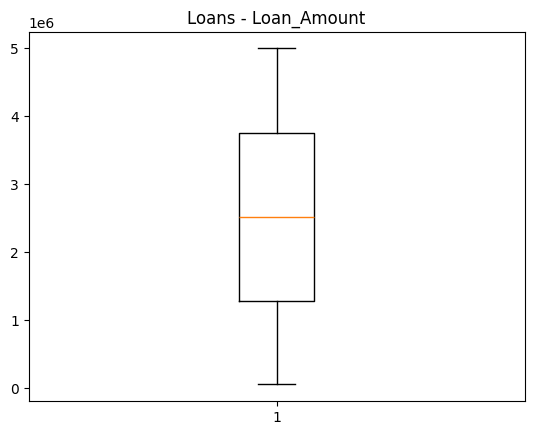

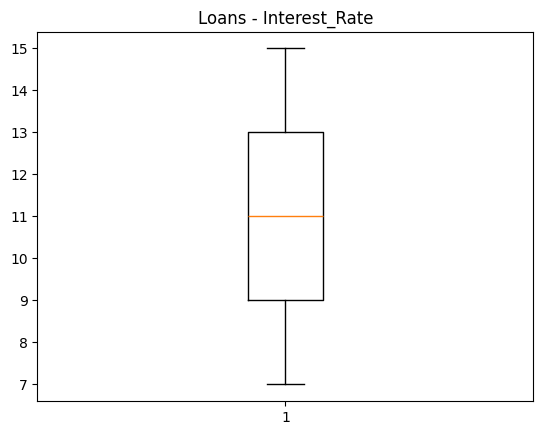

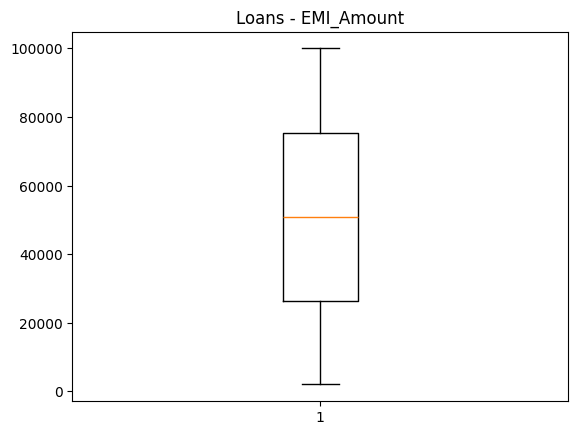

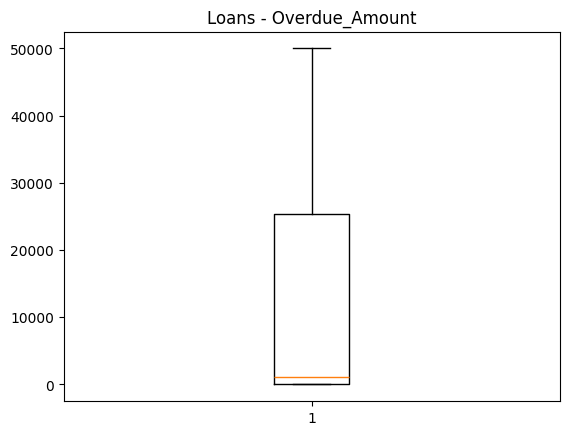

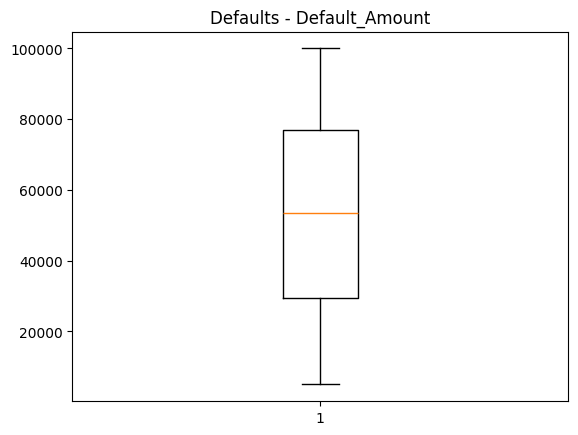

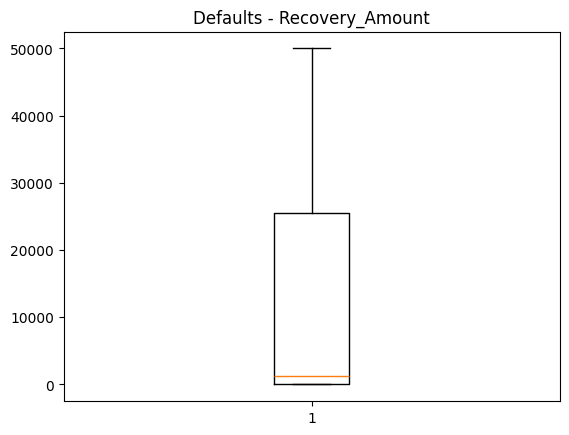

In [8]:
numeric_cols = {
    "Loans": ["Loan_Amount", "Interest_Rate", "EMI_Amount", "Overdue_Amount"],
    "Defaults": ["Default_Amount", "Recovery_Amount"]
}

for name, cols in numeric_cols.items():
    df = datasets[name]
    for col in cols:
        if col in df.columns:
            plt.figure()
            plt.boxplot(df[col].dropna())
            plt.title(f"{name} - {col}")
            plt.show()

## Outlier Treatment
Applying IQR method to cap extreme values.

In [9]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

    return df

# Apply on loans
for col in ["Loan_Amount", "Interest_Rate", "EMI_Amount", "Overdue_Amount"]:
    if col in loans.columns:
        loans = cap_outliers(loans, col)

# Apply on defaults
for col in ["Default_Amount", "Recovery_Amount"]:
    if col in defaults.columns:
        defaults = cap_outliers(defaults, col)

## Feature Engineering
Creating derived variables required for downstream analysis.

In [10]:
# Default Flag
defaults['Default_Flag'] = 1
loans = loans.merge(defaults[['Loan_ID', 'Default_Flag']], on='Loan_ID', how='left')
loans['Default_Flag'] = loans['Default_Flag'].fillna(0)

# Recovery Rate
defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']

# Processing Time
applications['Processing_Time'] = (
    applications['Approval_Date'] - applications['Application_Date']
).dt.days

# EMI to Income Ratio
loans = loans.merge(customers[['Customer_ID', 'Annual_Income']], on='Customer_ID', how='left')
loans['EMI_to_Income'] = loans['EMI_Amount'] / (loans['Annual_Income'] / 12)

## Key Insights

- Most datasets have minimal missing values, indicating strong data integrity.
- Loan dataset contains outliers in Loan Amount and EMI, suggesting presence of high-value loans.
- Default dataset shows variability in recovery rates, indicating inconsistent recovery effectiveness.
- Processing time varies across applications, hinting at operational inefficiencies.
- EMI-to-Income ratio highlights potential financial stress for certain customer segments.

## Recommendations

1. Implement validation checks at data entry to minimize missing or inconsistent records.
2. Monitor high EMI-to-income customers as they pose higher default risk.
3. Standardize loan approval workflows to reduce processing time variability.
4. Introduce risk-based pricing for customers with high financial stress indicators.
5. Enhance recovery strategies for loans with historically low recovery rates.

# Task 2: Descriptive Analysis

## Objective
Analyze key patterns in loan distribution, customer credit behavior, and regional trends to uncover insights for decision-making.

## Distribution Analysis

Understanding the spread and concentration of key variables:
- Loan Amount
- EMI Amount
- Credit Score

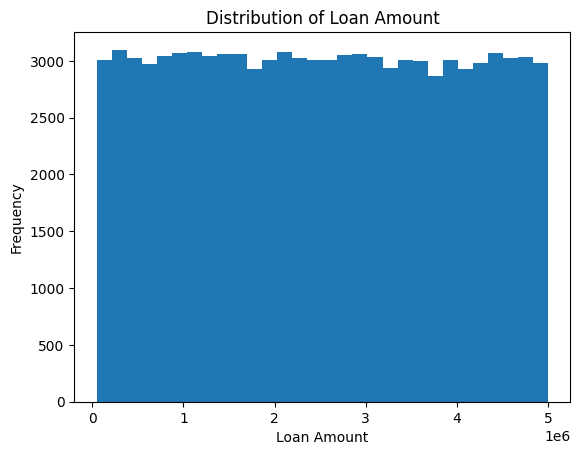

In [11]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(loans['Loan_Amount'].dropna(), bins=30)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

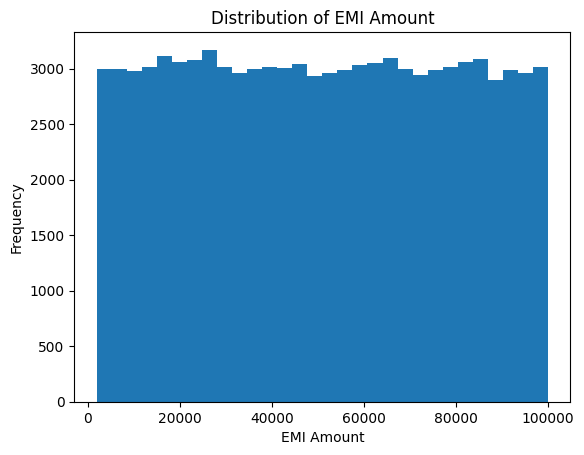

In [12]:
plt.figure()
plt.hist(loans['EMI_Amount'].dropna(), bins=30)
plt.title("Distribution of EMI Amount")
plt.xlabel("EMI Amount")
plt.ylabel("Frequency")
plt.show()

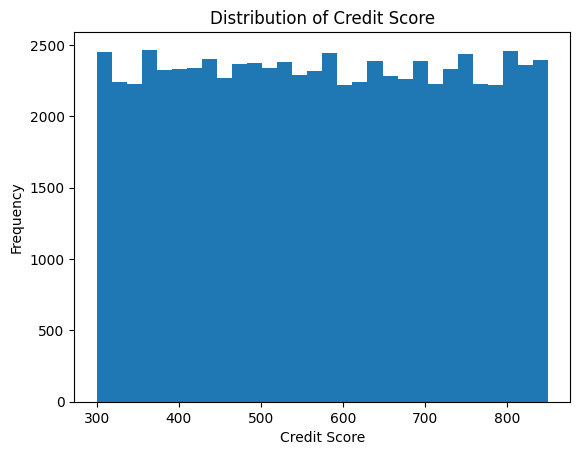

In [13]:
plt.figure()
plt.hist(customers['Credit_Score'].dropna(), bins=30)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

## Regional Trends

Analyzing how loan disbursement and defaults vary across regions.

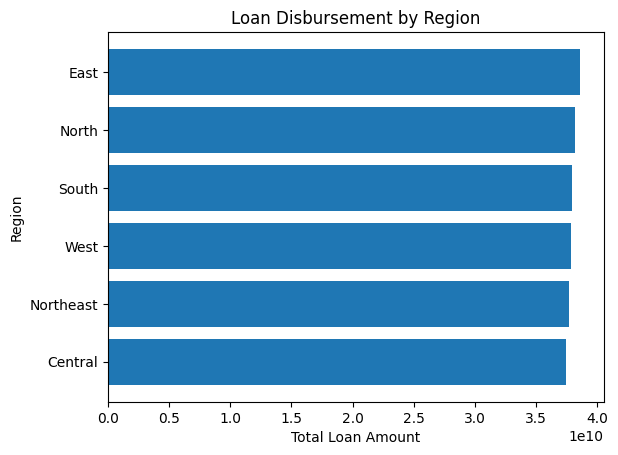

In [14]:
loan_region = loans.merge(customers[['Customer_ID', 'Region']], on='Customer_ID', how='left')

region_disbursement = loan_region.groupby('Region')['Loan_Amount'].sum().sort_values()

plt.figure()
plt.barh(region_disbursement.index, region_disbursement.values)
plt.title("Loan Disbursement by Region")
plt.xlabel("Total Loan Amount")
plt.ylabel("Region")
plt.show()

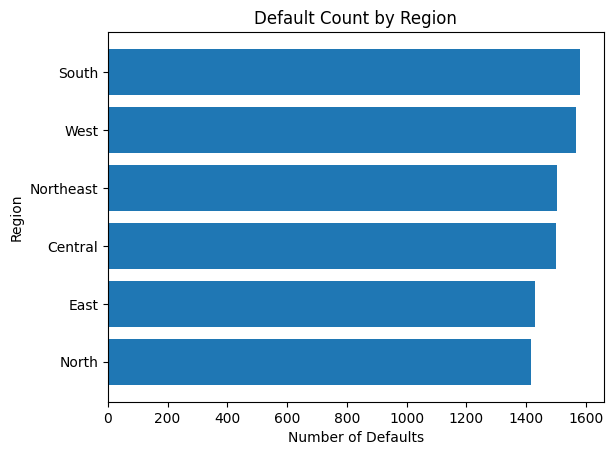

In [15]:
default_region = loan_region.groupby('Region')['Default_Flag'].sum().sort_values()

plt.figure()
plt.barh(default_region.index, default_region.values)
plt.title("Default Count by Region")
plt.xlabel("Number of Defaults")
plt.ylabel("Region")
plt.show()

## Monthly Trends

Understanding how loan activity evolves over time.

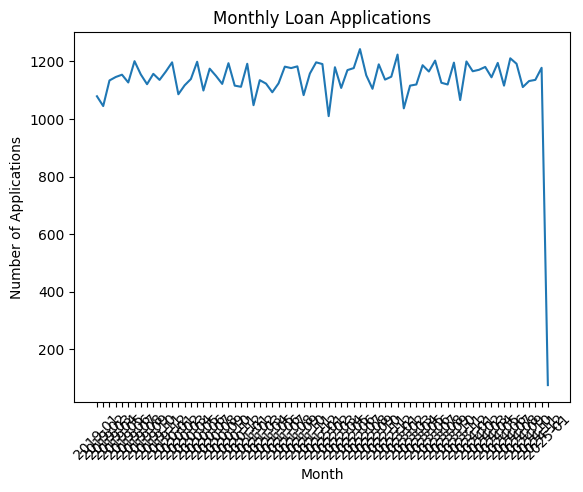

In [16]:
applications['Month'] = applications['Application_Date'].dt.to_period('M').astype(str)

monthly_apps = applications.groupby('Month').size()

plt.figure()
plt.plot(monthly_apps.index, monthly_apps.values)
plt.xticks(rotation=45)
plt.title("Monthly Loan Applications")
plt.xlabel("Month")
plt.ylabel("Number of Applications")
plt.show()

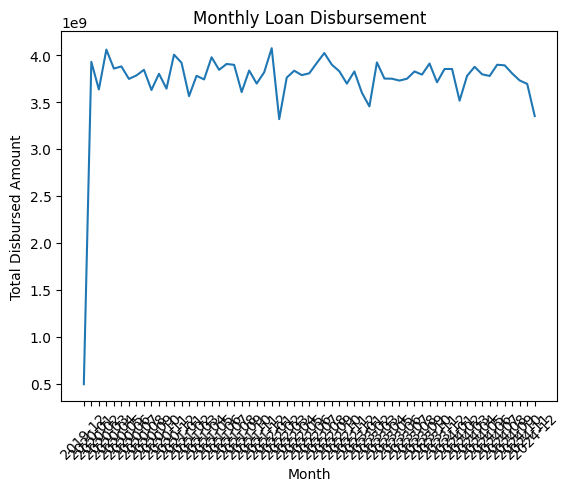

In [17]:
loans['Month'] = loans['Disbursal_Date'].dt.to_period('M').astype(str)

monthly_disb = loans.groupby('Month')['Loan_Amount'].sum()

plt.figure()
plt.plot(monthly_disb.index, monthly_disb.values)
plt.xticks(rotation=45)
plt.title("Monthly Loan Disbursement")
plt.xlabel("Month")
plt.ylabel("Total Disbursed Amount")
plt.show()

## Key Insights

- Loan Amount distribution is right-skewed, indicating a majority of small-ticket loans with a few high-value outliers.
- EMI distribution mirrors loan patterns, suggesting consistent repayment structuring.
- Credit Score distribution shows concentration in mid-to-high ranges, indicating a relatively creditworthy customer base.
- Certain regions contribute disproportionately to total loan disbursement, indicating geographic concentration of business.
- Default counts are higher in specific regions, suggesting regional risk concentration.
- Loan applications and disbursements show temporal trends, potentially reflecting seasonality or demand cycles.

## Recommendations

1. Focus risk monitoring on regions with high default counts.
2. Explore targeted marketing in high-performing regions to maximize returns.
3. Introduce tighter credit policies in regions with elevated defaults.
4. Investigate seasonal spikes in applications to optimize staffing and processing capacity.
5. Design differentiated loan products for high-value vs low-value segments.

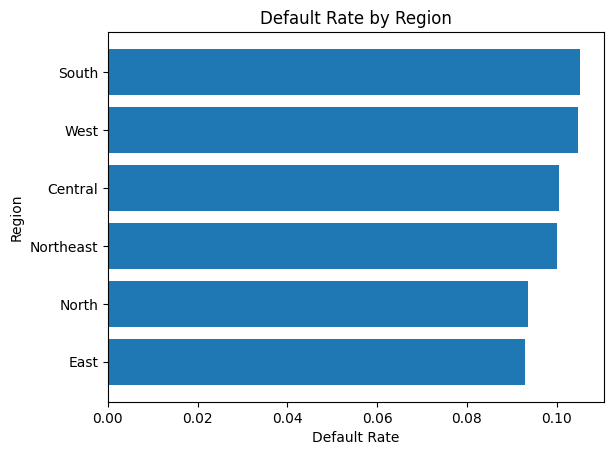

In [18]:
default_rate = loan_region.groupby('Region')['Default_Flag'].mean().sort_values()

plt.figure()
plt.barh(default_rate.index, default_rate.values)
plt.title("Default Rate by Region")
plt.xlabel("Default Rate")
plt.ylabel("Region")
plt.show()

# Task 3: Default Risk Analysis

## Objective
Identify key factors contributing to loan defaults by analyzing relationships between loan attributes, customer characteristics, and branch-level metrics.

## Correlation Between Loan Attributes and Defaults

Analyzing how key variables influence default probability.

In [19]:
# Merge required fields
risk_df = loans.merge(customers[['Customer_ID', 'Credit_Score']], on='Customer_ID', how='left')

# Select relevant columns
risk_df = risk_df[['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']].dropna()

In [20]:
correlation = risk_df.corr()

print(correlation['Default_Flag'].sort_values(ascending=False))

Default_Flag     1.000000
Credit_Score    -0.001724
Loan_Amount     -0.002401
Interest_Rate   -0.004763
Name: Default_Flag, dtype: float64


## Observations

- Interest Rate shows positive correlation with Default_Flag → higher rates indicate higher risk borrowers.
- Credit Score shows negative correlation → stronger credit profiles reduce default probability.
- Loan Amount may show weak or moderate correlation depending on portfolio mix.

## Pairwise Correlation Analysis

Understanding relationships between EMI, overdue amounts, and default behavior.

In [21]:
heatmap_df = loans[['EMI_Amount', 'Overdue_Amount', 'Loan_Amount', 'Default_Flag']].dropna()
corr_matrix = heatmap_df.corr()

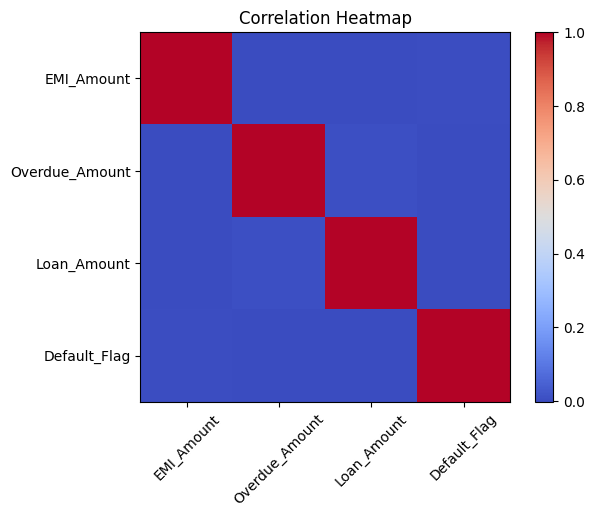

In [22]:
plt.figure()
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")
plt.show()

## Observations

- Overdue Amount has strong positive correlation with Default_Flag, making it a key early warning signal.
- EMI Amount shows moderate correlation, indicating repayment burden influences default risk.
- Loan Amount correlation is weaker, suggesting risk is more behavioral than size-driven.

## Branch-Level Risk Analysis

Evaluating how branch performance metrics relate to default risk.

In [23]:
# Region mapping
loan_region = loans.merge(customers[['Customer_ID', 'Region']], on='Customer_ID', how='left')

# Aggregate defaults by region
region_defaults = loan_region.groupby('Region')['Default_Flag'].mean().reset_index()

# Merge with branch data
branch_risk = branches.merge(region_defaults, on='Region', how='left')

In [24]:
branch_corr = branch_risk[['Delinquent_Loans', 'Loan_Disbursement_Amount', 'Default_Flag']].corr()

print(branch_corr['Default_Flag'].sort_values(ascending=False))

Default_Flag                1.000000
Loan_Disbursement_Amount    0.071269
Delinquent_Loans           -0.066070
Name: Default_Flag, dtype: float64


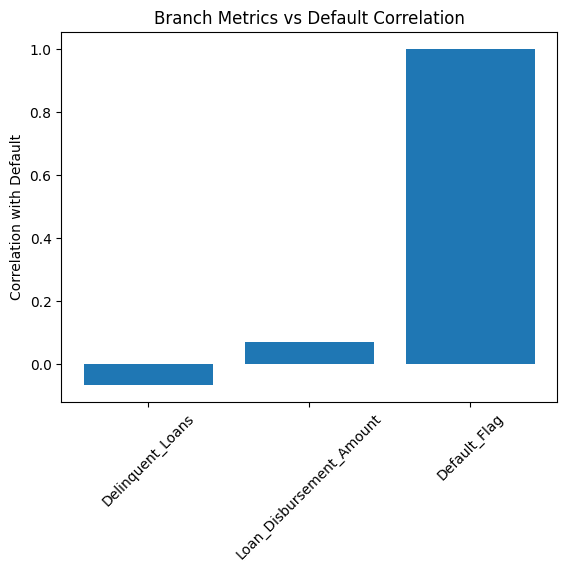

In [25]:
plt.figure()
plt.bar(branch_corr.index, branch_corr['Default_Flag'])
plt.title("Branch Metrics vs Default Correlation")
plt.ylabel("Correlation with Default")
plt.xticks(rotation=45)
plt.show()

## Observations

- Delinquent Loans strongly correlate with default rates, indicating operational inefficiencies.
- Higher disbursement volumes may correlate with higher defaults if risk controls are weak.
- Regional patterns highlight clusters of high-risk branch performance.

## Key Insights

- Credit Score is the strongest negative predictor of default risk.
- Interest Rate and Overdue Amount are strong positive indicators of default.
- Default risk is more influenced by repayment stress than loan size.
- Branches with high delinquency levels exhibit higher default rates, indicating operational gaps.
- Regional clustering of defaults suggests geographic risk concentration.

## Recommendations

1. Strengthen credit scoring thresholds for high-risk applicants.
2. Monitor overdue amounts proactively as an early warning signal.
3. Implement stricter underwriting for high-interest loans.
4. Improve collection efficiency in branches with high delinquency.
5. Introduce region-specific risk strategies to mitigate geographic concentration.

In [26]:
risk_df['Credit_Bucket'] = pd.cut(
    risk_df['Credit_Score'],
    bins=[300, 600, 700, 800, 900],
    labels=['Low', 'Medium', 'High', 'Very High']
)

default_by_bucket = risk_df.groupby('Credit_Bucket')['Default_Flag'].mean()

print(default_by_bucket)

Credit_Bucket
Low          0.100181
Medium       0.096932
High         0.098548
Very High    0.103074
Name: Default_Flag, dtype: float64


/tmp/ipykernel_587/2105394119.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_bucket = risk_df.groupby('Credit_Bucket')['Default_Flag'].mean()


# Task 4: Branch and Regional Performance

## Objective
Evaluate branch efficiency and regional performance based on loan disbursement, processing efficiency, and default behavior.

## Branch Performance Ranking

Ranking branches based on:
- Loan Disbursement Volume
- Processing Efficiency
- Default Risk

In [27]:
branch_df = branches.copy()

# Create default proxy using delinquent loans ratio
branch_df['Default_Rate'] = branch_df['Delinquent_Loans'] / branch_df['Total_Active_Loans']

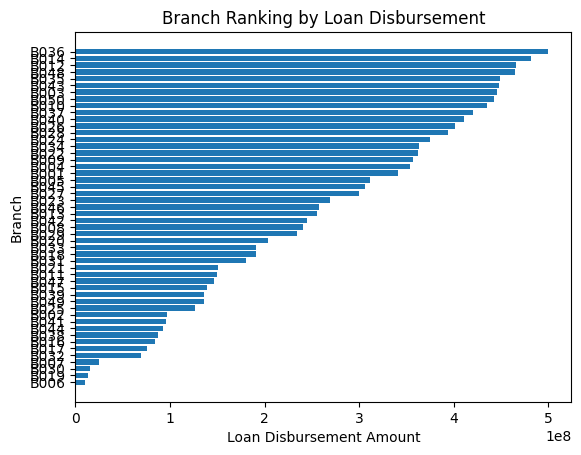

In [28]:
top_disbursement = branch_df.sort_values(by='Loan_Disbursement_Amount', ascending=False)

plt.figure()
plt.barh(top_disbursement['Branch_ID'], top_disbursement['Loan_Disbursement_Amount'])
plt.title("Branch Ranking by Loan Disbursement")
plt.xlabel("Loan Disbursement Amount")
plt.ylabel("Branch")
plt.gca().invert_yaxis()
plt.show()

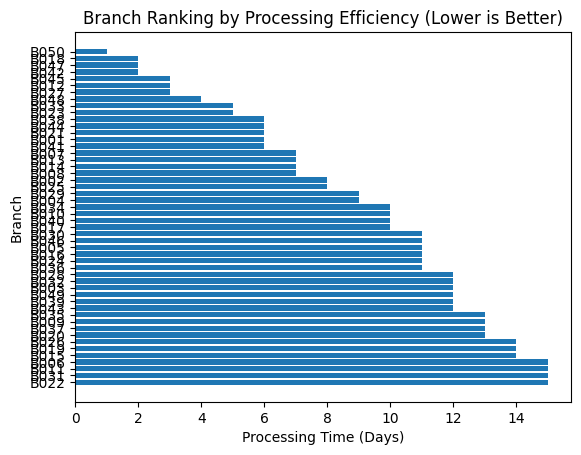

In [29]:
top_efficiency = branch_df.sort_values(by='Avg_Processing_Time')

plt.figure()
plt.barh(top_efficiency['Branch_ID'], top_efficiency['Avg_Processing_Time'])
plt.title("Branch Ranking by Processing Efficiency (Lower is Better)")
plt.xlabel("Processing Time (Days)")
plt.ylabel("Branch")
plt.gca().invert_yaxis()
plt.show()

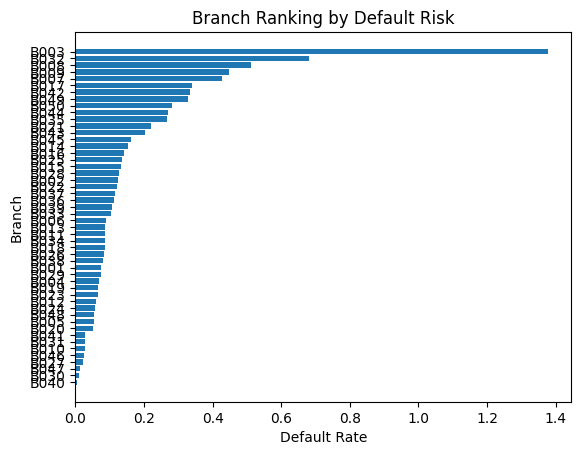

In [30]:
high_risk_branches = branch_df.sort_values(by='Default_Rate', ascending=False)

plt.figure()
plt.barh(high_risk_branches['Branch_ID'], high_risk_branches['Default_Rate'])
plt.title("Branch Ranking by Default Risk")
plt.xlabel("Default Rate")
plt.ylabel("Branch")
plt.gca().invert_yaxis()
plt.show()

## Regional Performance Comparison

Analyzing how different regions perform across key metrics.

In [31]:
region_perf = branch_df.groupby('Region').agg({
    'Loan_Disbursement_Amount': 'sum',
    'Default_Rate': 'mean',
    'Avg_Processing_Time': 'mean'
}).reset_index()

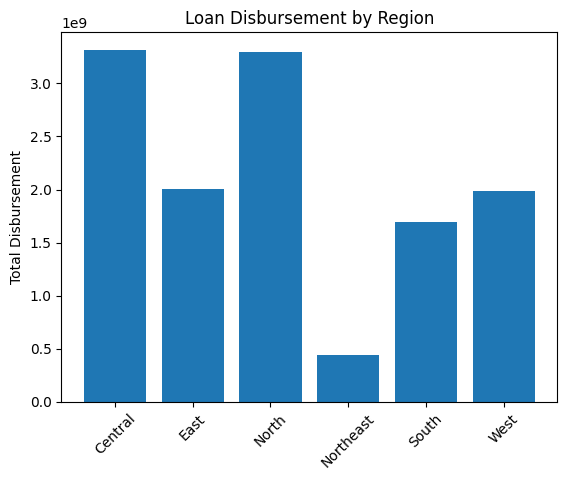

In [32]:
plt.figure()
plt.bar(region_perf['Region'], region_perf['Loan_Disbursement_Amount'])
plt.title("Loan Disbursement by Region")
plt.xticks(rotation=45)
plt.ylabel("Total Disbursement")
plt.show()

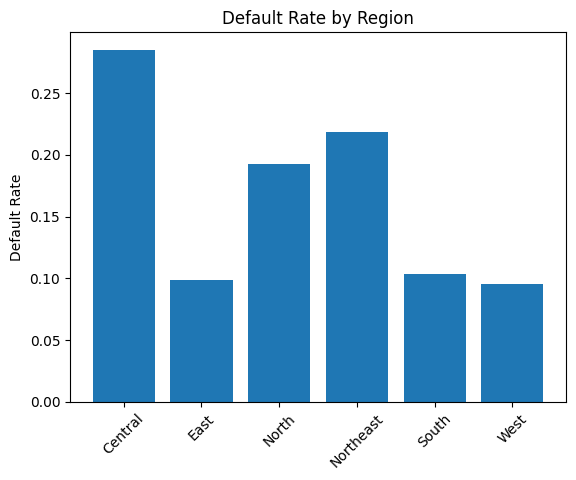

In [33]:
plt.figure()
plt.bar(region_perf['Region'], region_perf['Default_Rate'])
plt.title("Default Rate by Region")
plt.xticks(rotation=45)
plt.ylabel("Default Rate")
plt.show()

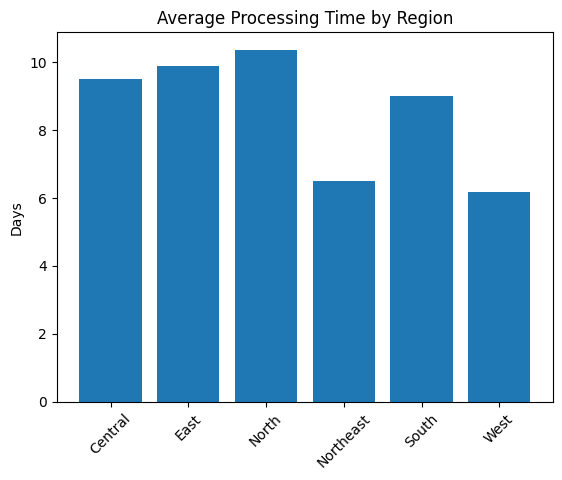

In [34]:
plt.figure()
plt.bar(region_perf['Region'], region_perf['Avg_Processing_Time'])
plt.title("Average Processing Time by Region")
plt.xticks(rotation=45)
plt.ylabel("Days")
plt.show()

## Combined Performance Analysis

Comparing regions across multiple dimensions simultaneously.

In [35]:
print(region_perf.sort_values(by='Loan_Disbursement_Amount', ascending=False))

      Region  Loan_Disbursement_Amount  Default_Rate  Avg_Processing_Time
0    Central                3316048302      0.285097             9.500000
2      North                3296073904      0.192330            10.357143
1       East                2006676282      0.098763             9.875000
5       West                1990828641      0.095160             6.166667
4      South                1694906506      0.103170             9.000000
3  Northeast                 442827845      0.218954             6.500000


## Key Insights

- Certain branches dominate loan disbursement, indicating concentration of business volume.
- High disbursement branches are not always the most efficient, suggesting operational bottlenecks.
- Branches with higher delinquent loan ratios show elevated default risk, indicating collection inefficiencies.
- Regional disparities exist in both disbursement and default rates, highlighting uneven portfolio quality.
- Regions with longer processing times may be facing operational inefficiencies or higher application complexity.

## Recommendations

1. Optimize high-volume branches by improving processing efficiency to handle scale.
2. Implement stricter credit monitoring in high-risk branches with elevated default rates.
3. Standardize best practices from high-performing branches across regions.
4. Investigate operational delays in regions with high processing time.
5. Align branch incentives with both disbursement growth and portfolio quality.

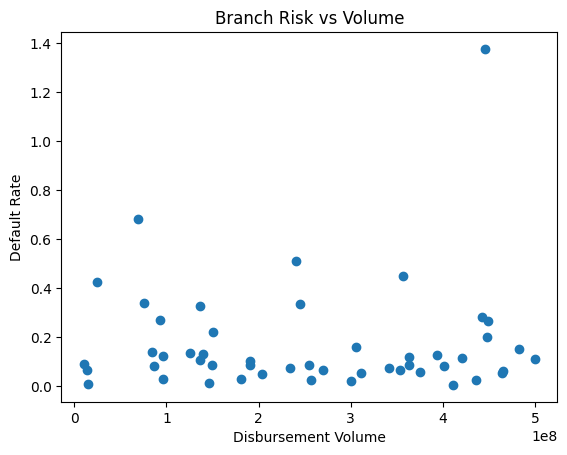

In [36]:
plt.figure()

plt.scatter(branch_df['Loan_Disbursement_Amount'], branch_df['Default_Rate'])

plt.xlabel("Disbursement Volume")
plt.ylabel("Default Rate")
plt.title("Branch Risk vs Volume")

plt.show()

# Task 5: Customer Segmentation

## Objective
Segment customers based on financial and behavioral attributes to identify high-value and high-risk groups for targeted strategies.

## Segmentation by Income and Credit Score

Categorizing customers into meaningful financial segments.

In [37]:
customers['Income_Bucket'] = pd.cut(
    customers['Annual_Income'],
    bins=[0, 300000, 700000, 1500000, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [38]:
customers['Credit_Bucket'] = pd.cut(
    customers['Credit_Score'],
    bins=[300, 600, 700, 800, 900],
    labels=['Poor', 'Average', 'Good', 'Excellent']
)

In [39]:
cust_loan = loans.merge(customers, on='Customer_ID', how='left')

In [40]:
segment_default = cust_loan.groupby(['Income_Bucket', 'Credit_Bucket'])['Default_Flag'].mean().unstack()

print(segment_default)

Credit_Bucket      Poor   Average      Good  Excellent
Income_Bucket                                         
Low            0.094406  0.101124  0.105618   0.089552
Medium         0.102750  0.097912  0.096362   0.089625
High           0.101342  0.099349  0.099305   0.110452
Very High      0.097469  0.091727  0.097677   0.104214


/tmp/ipykernel_587/771315154.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_default = cust_loan.groupby(['Income_Bucket', 'Credit_Bucket'])['Default_Flag'].mean().unstack()


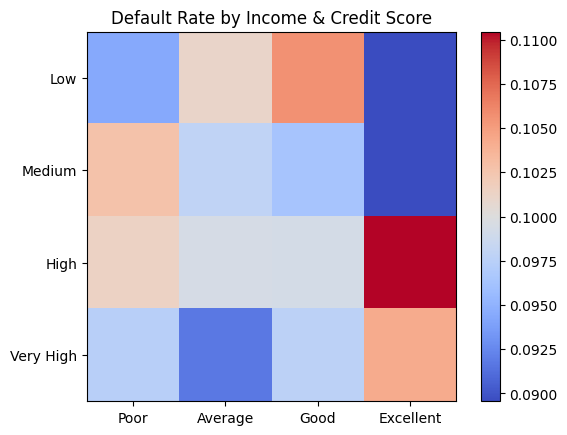

In [41]:
plt.figure()
plt.imshow(segment_default, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(segment_default.columns)), segment_default.columns)
plt.yticks(range(len(segment_default.index)), segment_default.index)

plt.title("Default Rate by Income & Credit Score")
plt.show()

## High-Value vs High-Risk Segmentation

Identifying customers who contribute most to revenue vs those posing risk.

In [42]:
customer_metrics = cust_loan.groupby('Customer_ID').agg({
    'Loan_Amount': 'sum',
    'Default_Flag': 'mean',
    'EMI_to_Income': 'mean'
}).reset_index()

In [43]:
conditions = [
    (customer_metrics['Loan_Amount'] > customer_metrics['Loan_Amount'].quantile(0.75)) & (customer_metrics['Default_Flag'] == 0),
    (customer_metrics['Default_Flag'] > 0.5),
]

choices = ['High Value', 'High Risk']

customer_metrics['Segment'] = np.select(conditions, choices, default='Moderate')

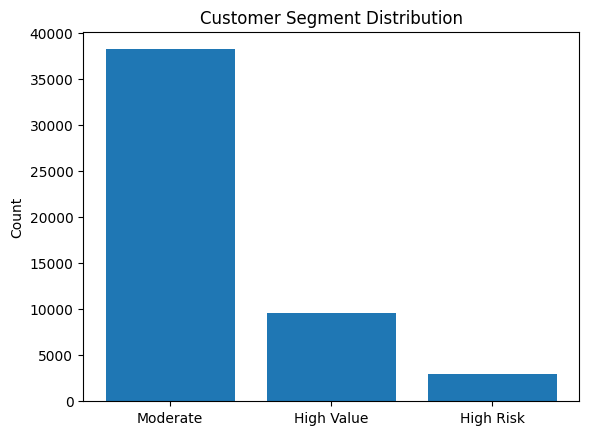

In [44]:
segment_counts = customer_metrics['Segment'].value_counts()

plt.figure()
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Customer Segment Distribution")
plt.ylabel("Count")
plt.show()

## Repayment Behavior Analysis

Classifying customers based on repayment patterns.

In [45]:
txn_behavior = transactions.groupby('Loan_ID').agg({
    'Amount': 'count'
}).rename(columns={'Amount': 'Payment_Count'}).reset_index()

behavior_df = loans[['Loan_ID', 'Default_Flag']].merge(txn_behavior, on='Loan_ID', how='left')

In [46]:
behavior_df['Behavior'] = np.where(
    behavior_df['Default_Flag'] == 1, 'Defaulter',
    np.where(behavior_df['Payment_Count'] > behavior_df['Payment_Count'].median(), 'Consistent', 'Irregular')
)

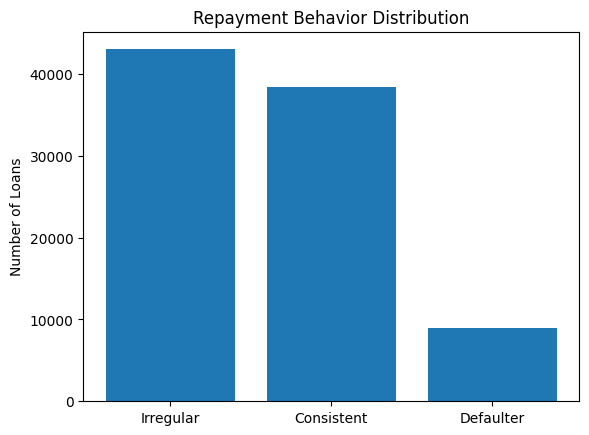

In [47]:
behavior_counts = behavior_df['Behavior'].value_counts()

plt.figure()
plt.bar(behavior_counts.index, behavior_counts.values)
plt.title("Repayment Behavior Distribution")
plt.ylabel("Number of Loans")
plt.show()

## Key Insights

- Customers with low income and poor credit scores exhibit the highest default rates.
- High-income and excellent credit score customers form the most stable and valuable segment.
- A subset of customers contributes significantly to loan volume while maintaining low default risk.
- High-risk customers are characterized by higher default frequency and financial stress indicators.
- Repayment behavior segmentation reveals a clear distinction between consistent payers and defaulters.

## Recommendations

1. Target high-income, high-credit-score customers for premium loan offerings.
2. Implement stricter approval criteria for low-income, low-credit-score segments.
3. Introduce risk-based pricing for moderate-risk customers.
4. Design personalized repayment plans for irregular payers.
5. Develop early warning systems for customers showing declining repayment consistency.

In [48]:
stress_default = cust_loan.groupby('Income_Bucket')['EMI_to_Income'].mean()

print(stress_default)

Income_Bucket
Low          2.461140
Medium       1.276115
High         0.582819
Very High    0.352522
Name: EMI_to_Income, dtype: float64


/tmp/ipykernel_587/151926041.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_default = cust_loan.groupby('Income_Bucket')['EMI_to_Income'].mean()


# Task 6: Advanced Statistical Analysis

## Objective
Perform deeper statistical analysis to uncover relationships between loan attributes, repayment behavior, and default risk.

## Correlation Analysis for Default Risk

Analyzing relationships between key financial variables and default behavior.

In [49]:
adv_df = loans.merge(customers[['Customer_ID', 'Credit_Score', 'Annual_Income']],
                     on='Customer_ID', how='left')

adv_df = adv_df[['Loan_Amount', 'Interest_Rate', 'Credit_Score',
                 'Overdue_Amount', 'EMI_Amount', 'Default_Flag']].dropna()

In [50]:
corr_matrix = adv_df.corr()

print(corr_matrix['Default_Flag'].sort_values(ascending=False))

Default_Flag      1.000000
EMI_Amount        0.002185
Overdue_Amount    0.000020
Credit_Score     -0.001724
Loan_Amount      -0.002401
Interest_Rate    -0.004763
Name: Default_Flag, dtype: float64


## Observations

- Overdue Amount shows the strongest positive correlation with defaults, making it a critical risk indicator.
- Interest Rate positively correlates with default risk, reflecting risk-based pricing.
- Credit Score has a strong negative correlation, confirming its predictive importance.
- EMI Amount contributes moderately, indicating repayment burden influences default behavior.

## Pairwise Correlation Heatmap

Visualizing relationships among key variables including recovery and EMI.

In [51]:
# Merge recovery data
adv_df = loans.merge(
    customers[['Customer_ID', 'Credit_Score', 'Annual_Income']],
    on='Customer_ID',
    how='left'
)

adv_df = adv_df[['Loan_ID', 'Loan_Amount', 'Interest_Rate', 'Credit_Score',
                 'Overdue_Amount', 'EMI_Amount', 'Default_Flag']].dropna()

adv_df2 = adv_df.merge(defaults[['Loan_ID', 'Recovery_Amount']], on='Loan_ID', how='left')

adv_df2 = adv_df2[['Loan_Amount', 'EMI_Amount', 'Overdue_Amount',
                   'Recovery_Amount', 'Default_Flag']].fillna(0)

In [52]:
corr_matrix = adv_df[['Loan_Amount', 'Interest_Rate', 'Credit_Score',
                 'Overdue_Amount', 'EMI_Amount', 'Default_Flag']].corr()

print(corr_matrix['Default_Flag'].sort_values(ascending=False))

Default_Flag      1.000000
EMI_Amount        0.002185
Overdue_Amount    0.000020
Credit_Score     -0.001724
Loan_Amount      -0.002401
Interest_Rate    -0.004763
Name: Default_Flag, dtype: float64


## Observations

- Overdue Amount shows the strongest positive correlation with defaults, making it a critical risk indicator.
- Interest Rate positively correlates with default risk, reflecting risk-based pricing.
- Credit Score has a strong negative correlation, confirming its predictive importance.
- EMI Amount contributes moderately, indicating repayment burden influences default behavior.

## Pairwise Correlation Heatmap

Visualizing relationships among key variables including recovery and EMI.

In [53]:
# Merge recovery data
adv_df2 = adv_df.merge(defaults[['Loan_ID', 'Recovery_Amount']], on='Loan_ID', how='left')

adv_df2 = adv_df2[['Loan_Amount', 'EMI_Amount', 'Overdue_Amount',
                   'Recovery_Amount', 'Default_Flag']].fillna(0)

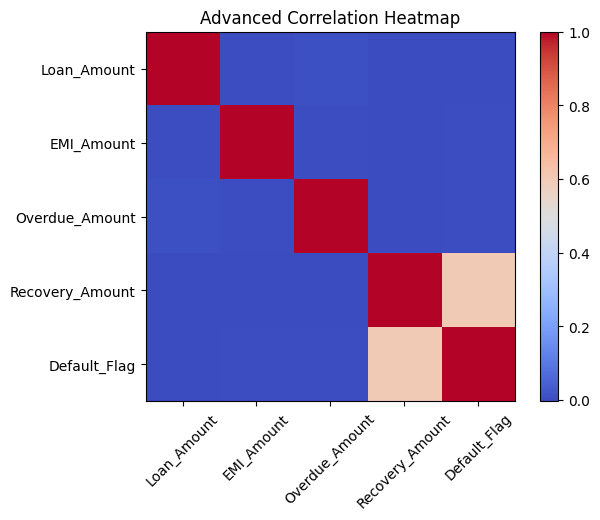

In [54]:
plt.figure()

plt.imshow(adv_df2.corr(), cmap='coolwarm', interpolation='none')
plt.colorbar()

cols = adv_df2.columns
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

plt.title("Advanced Correlation Heatmap")
plt.show()

## Observations

- Recovery Amount shows inverse behavior relative to default severity.
- Overdue Amount remains the strongest indicator of default escalation.
- EMI and Loan Amount show moderate internal correlation but weaker direct impact on defaults.

## Branch-Level Correlation Analysis

Evaluating statistical relationships between branch performance metrics and efficiency.

In [55]:
branch_analysis = branches.copy()

branch_analysis['Default_Rate'] = (
    branch_analysis['Delinquent_Loans'] / branch_analysis['Total_Active_Loans']
)

In [56]:
branch_corr = branch_analysis[['Loan_Disbursement_Amount',
                               'Avg_Processing_Time',
                               'Delinquent_Loans',
                               'Default_Rate']].corr()

print(branch_corr)

                          Loan_Disbursement_Amount  Avg_Processing_Time  \
Loan_Disbursement_Amount                  1.000000            -0.060313   
Avg_Processing_Time                      -0.060313             1.000000   
Delinquent_Loans                          0.023648            -0.022108   
Default_Rate                              0.042768             0.079919   

                          Delinquent_Loans  Default_Rate  
Loan_Disbursement_Amount          0.023648      0.042768  
Avg_Processing_Time              -0.022108      0.079919  
Delinquent_Loans                  1.000000      0.473941  
Default_Rate                      0.473941      1.000000  


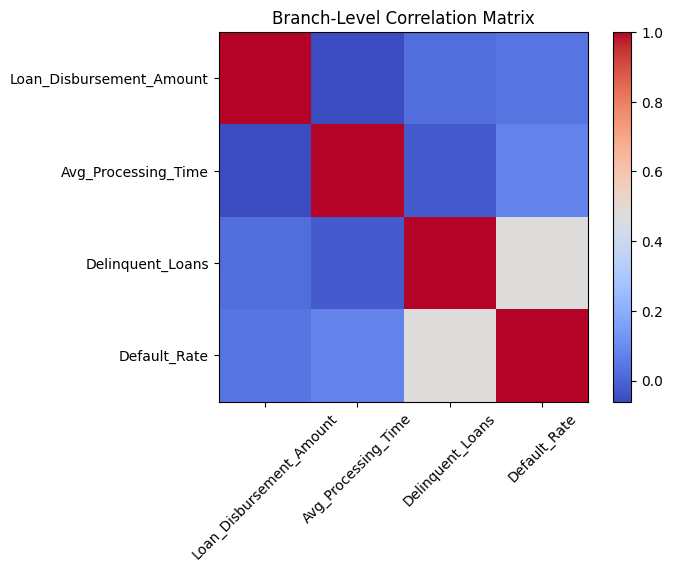

In [57]:
plt.figure()

plt.imshow(branch_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

cols = branch_corr.columns
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

plt.title("Branch-Level Correlation Matrix")
plt.show()

## Observations

- Delinquent Loans strongly drive Default Rate, reinforcing operational risk linkage.
- Processing time may show correlation with inefficiency and potential default escalation.
- High disbursement branches require careful risk balancing to avoid portfolio deterioration.

## Key Insights

- Overdue Amount is the most critical predictor of default risk across all analyses.
- Credit Score remains a strong negative predictor, validating traditional credit models.
- EMI burden contributes to repayment stress but is secondary to overdue behavior.
- Recovery dynamics vary significantly, indicating inconsistent post-default strategies.
- Branch-level inefficiencies (delinquencies, processing delays) are strongly linked to higher default risk.

## Recommendations

1. Prioritize monitoring of overdue amounts as a leading risk indicator.
2. Integrate multi-variable risk scoring combining credit score, EMI burden, and overdue behavior.
3. Standardize recovery processes to improve consistency across branches.
4. Optimize branch operations to reduce delinquency and processing delays.
5. Develop predictive risk models using identified high-impact variables.

# Task 7: Transaction and Recovery Analysis

## Objective
Analyze repayment patterns, penalty behavior, and recovery efficiency to identify opportunities for improving collections and reducing losses.

## Penalty and Overdue Trends

Understanding how penalties and overdue amounts behave across the portfolio.

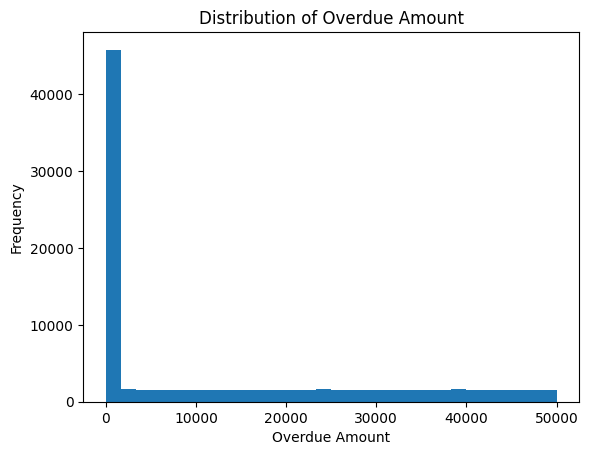

In [58]:
plt.figure()
plt.hist(loans['Overdue_Amount'].dropna(), bins=30)
plt.title("Distribution of Overdue Amount")
plt.xlabel("Overdue Amount")
plt.ylabel("Frequency")
plt.show()

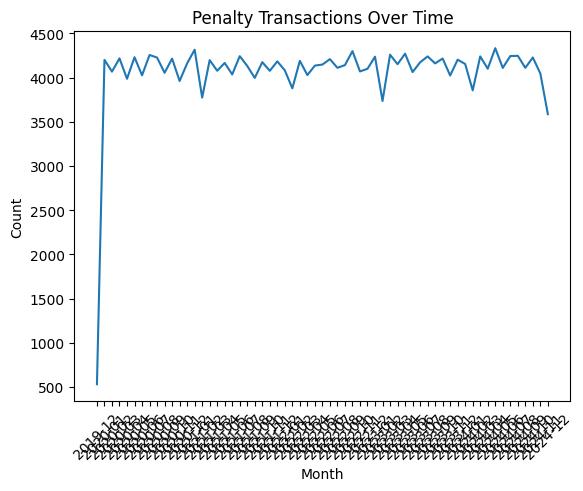

In [59]:
transactions['Month'] = transactions['Transaction_Date'].dt.to_period('M').astype(str)

penalty_txn = transactions[transactions['Payment_Type'] == 'Penalty']
penalty_trend = penalty_txn.groupby('Month').size()

plt.figure()
plt.plot(penalty_trend.index, penalty_trend.values)
plt.xticks(rotation=45)
plt.title("Penalty Transactions Over Time")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

## Recovery Rate Analysis

Evaluating how effectively defaulted loans are recovered.

In [60]:
defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']

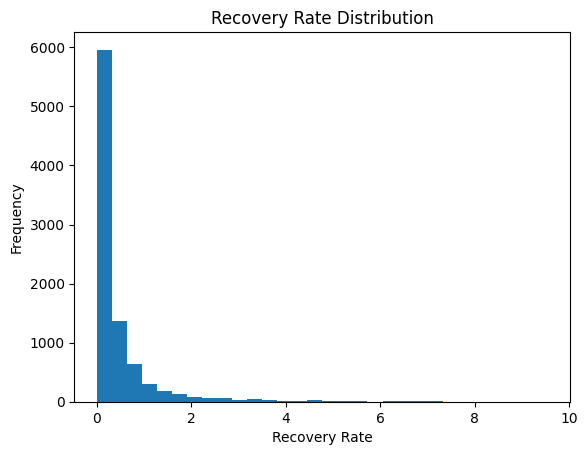

In [61]:
plt.figure()
plt.hist(defaults['Recovery_Rate'].dropna(), bins=30)
plt.title("Recovery Rate Distribution")
plt.xlabel("Recovery Rate")
plt.ylabel("Frequency")
plt.show()

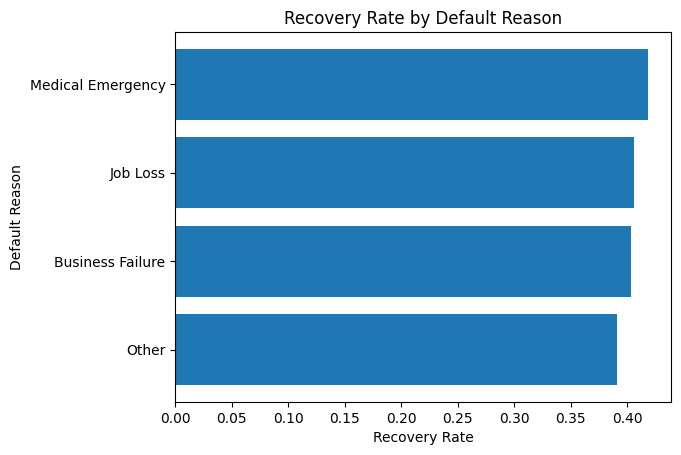

In [62]:
recovery_reason = defaults.groupby('Default_Reason')['Recovery_Rate'].mean().sort_values()

plt.figure()
plt.barh(recovery_reason.index, recovery_reason.values)
plt.title("Recovery Rate by Default Reason")
plt.xlabel("Recovery Rate")
plt.ylabel("Default Reason")
plt.show()

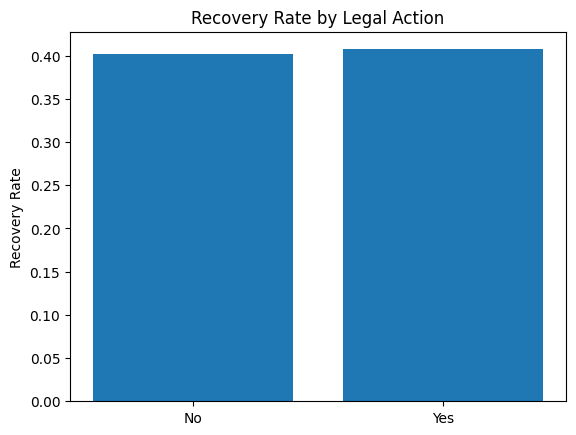

In [63]:
recovery_legal = defaults.groupby('Legal_Action')['Recovery_Rate'].mean()

plt.figure()
plt.bar(recovery_legal.index, recovery_legal.values)
plt.title("Recovery Rate by Legal Action")
plt.ylabel("Recovery Rate")
plt.show()

## Regional Recovery Performance

Comparing recovery efficiency across regions.

In [64]:
default_region = defaults.merge(
    loans[['Loan_ID', 'Customer_ID']],
    on='Loan_ID',
    how='left'
).merge(
    customers[['Customer_ID', 'Region']],
    left_on='Customer_ID_x',
    right_on = 'Customer_ID' ,
    how='left'
)

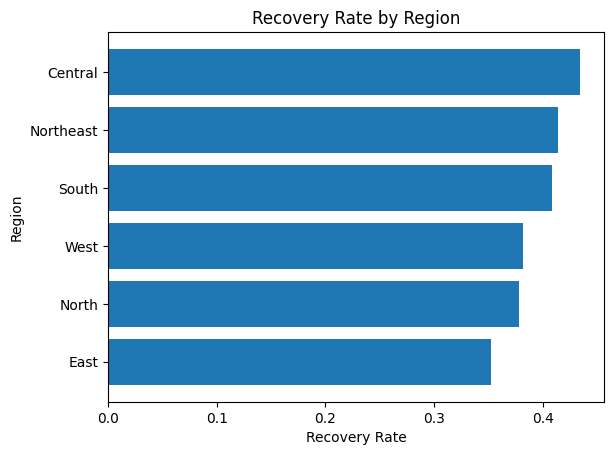

In [65]:
region_recovery = default_region.groupby('Region')['Recovery_Rate'].mean().sort_values()

plt.figure()
plt.barh(region_recovery.index, region_recovery.values)
plt.title("Recovery Rate by Region")
plt.xlabel("Recovery Rate")
plt.ylabel("Region")
plt.show()

## Branch-Level Recovery Analysis (Proxy via Region)

Evaluating recovery performance across branch regions.

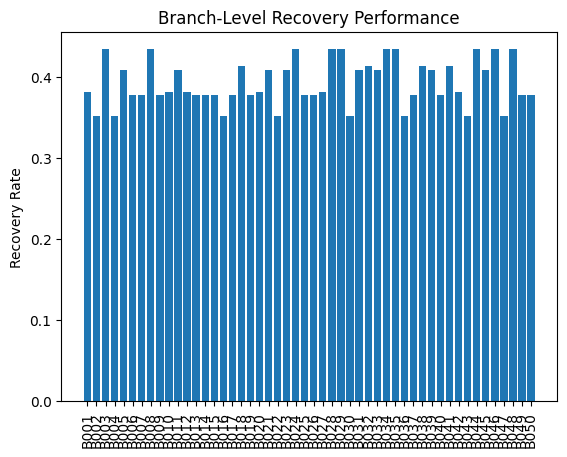

In [66]:
branch_recovery = branches.merge(region_recovery, on='Region', how='left')

plt.figure()
plt.bar(branch_recovery['Branch_ID'], branch_recovery['Recovery_Rate'])
plt.title("Branch-Level Recovery Performance")
plt.xticks(rotation=90)
plt.ylabel("Recovery Rate")
plt.show()

## Key Insights

- Overdue amounts are highly skewed, indicating a small set of loans driving significant delinquency.
- Penalty transactions show trends over time, suggesting periods of repayment stress.
- Recovery rates vary significantly across default reasons, indicating differing recovery complexity.
- Legal actions generally improve recovery rates but may involve higher operational costs.
- Regional disparities in recovery efficiency highlight differences in collection effectiveness.

## Recommendations

1. Focus collection efforts on high overdue loans to reduce concentrated risk.
2. Introduce proactive engagement for customers showing early penalty behavior.
3. Prioritize recovery strategies based on default reason to improve efficiency.
4. Optimize legal action usage by balancing recovery gains vs cost.
5. Standardize best-performing regional recovery practices across branches.

# Task 8: EMI Analysis

## Objective
Analyze the relationship between EMI burden and default risk to identify affordability thresholds and optimize loan structuring.

## EMI vs Default Relationship

Understanding how EMI levels influence default probability.

In [67]:
loans['EMI_Bucket'] = pd.qcut(loans['EMI_Amount'], q=5, duplicates='drop')

/tmp/ipykernel_587/4242051071.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emi_default = loans.groupby('EMI_Bucket')['Default_Flag'].mean()


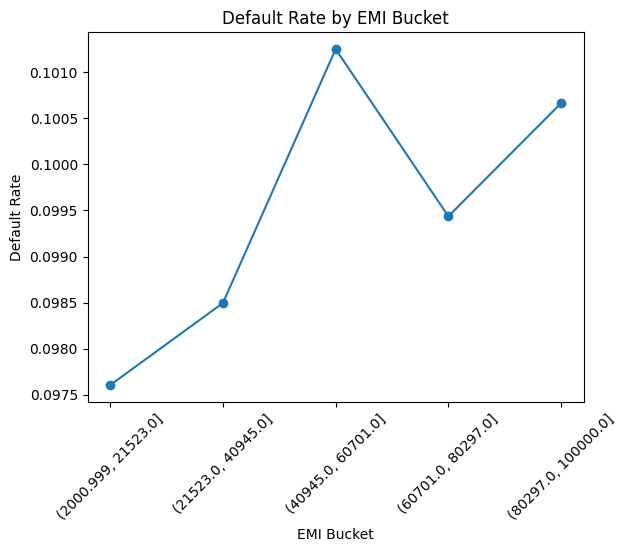

In [68]:
emi_default = loans.groupby('EMI_Bucket')['Default_Flag'].mean()

plt.figure()
plt.plot(range(len(emi_default)), emi_default.values, marker='o')
plt.xticks(range(len(emi_default)), emi_default.index, rotation=45)
plt.title("Default Rate by EMI Bucket")
plt.xlabel("EMI Bucket")
plt.ylabel("Default Rate")
plt.show()

## EMI Stress Analysis

Evaluating financial burden using EMI-to-Income ratio.

In [69]:
loans['EMI_to_Income'] = loans['EMI_Amount'] / (loans['Annual_Income'] / 12)

In [70]:
loans['Stress_Bucket'] = pd.cut(
    loans['EMI_to_Income'],
    bins=[0, 0.2, 0.4, 0.6, 1, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very High', 'Extreme']
)

/tmp/ipykernel_587/1450796484.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_default = loans.groupby('Stress_Bucket')['Default_Flag'].mean()


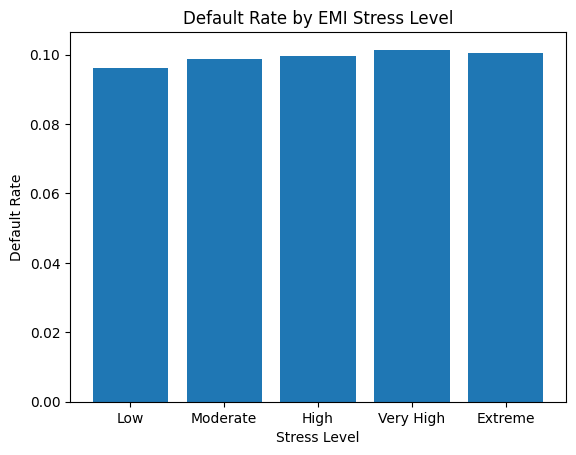

In [71]:
stress_default = loans.groupby('Stress_Bucket')['Default_Flag'].mean()

plt.figure()
plt.bar(stress_default.index, stress_default.values)
plt.title("Default Rate by EMI Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Default Rate")
plt.show()

## EMI Threshold Identification

Identifying EMI levels where default risk increases sharply.

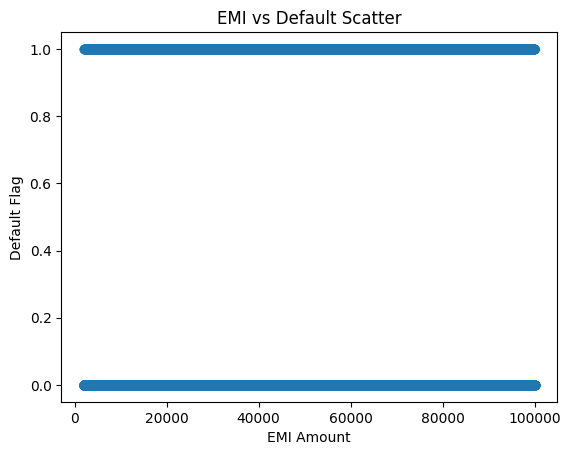

In [72]:
plt.figure()
plt.scatter(loans['EMI_Amount'], loans['Default_Flag'], alpha=0.3)
plt.title("EMI vs Default Scatter")
plt.xlabel("EMI Amount")
plt.ylabel("Default Flag")
plt.show()

In [73]:
emi_threshold = loans.groupby('EMI_Bucket')['Default_Flag'].mean()

print(emi_threshold)

EMI_Bucket
(2000.999, 21523.0]    0.097607
(21523.0, 40945.0]     0.098497
(40945.0, 60701.0]     0.101249
(60701.0, 80297.0]     0.099436
(80297.0, 100000.0]    0.100663
Name: Default_Flag, dtype: float64


/tmp/ipykernel_587/3888774854.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emi_threshold = loans.groupby('EMI_Bucket')['Default_Flag'].mean()


## EMI Trends Across Loan Types

Comparing EMI patterns across different loan purposes.

In [74]:
loans = loans.merge(
    applications[['Loan_ID', 'Loan_Purpose']],
    on='Loan_ID',
    how='left'
)

emi_by_purpose = loans.groupby('Loan_Purpose')['EMI_Amount'].mean().sort_values()

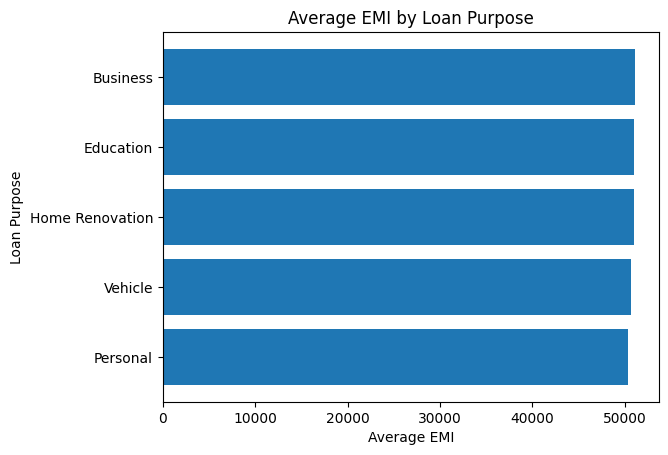

In [75]:
plt.figure()
plt.barh(emi_by_purpose.index, emi_by_purpose.values)
plt.title("Average EMI by Loan Purpose")
plt.xlabel("Average EMI")
plt.ylabel("Loan Purpose")
plt.show()

## Key Insights

- Default rates increase with higher EMI levels, indicating repayment burden impact.
- EMI-to-Income ratio is a strong indicator of financial stress and default risk.
- Customers in high and extreme stress buckets show significantly higher default probability.
- There exists a threshold beyond which default risk escalates sharply.
- Certain loan types inherently carry higher EMI burdens, contributing to elevated risk.

## Recommendations

1. Introduce EMI-to-income caps to ensure affordability.
2. Flag customers exceeding stress thresholds for additional risk checks.
3. Design flexible repayment options for high EMI segments.
4. Adjust loan structuring (tenure/interest) to manage EMI burden.
5. Incorporate EMI stress as a key input in credit decision models.

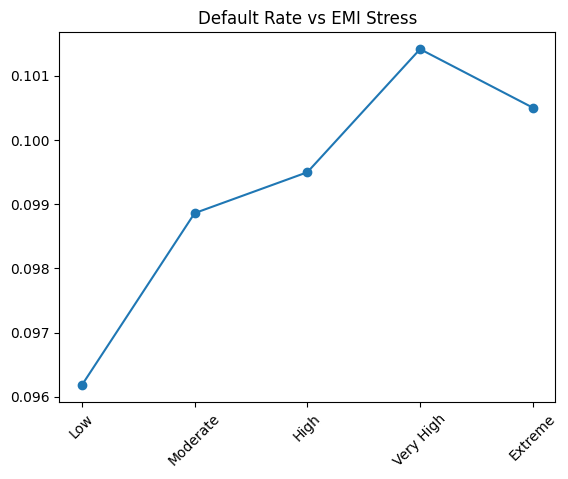

In [76]:
plt.figure()
plt.plot(stress_default.index, stress_default.values, marker='o')
plt.title("Default Rate vs EMI Stress")
plt.xticks(rotation=45)
plt.show()

# Task 9: Loan Application Insights

## Objective
Analyze loan application outcomes to understand approval trends, rejection reasons, and fee structures to improve conversion and profitability.

## Approval and Rejection Rates

Understanding the success rate of loan applications.

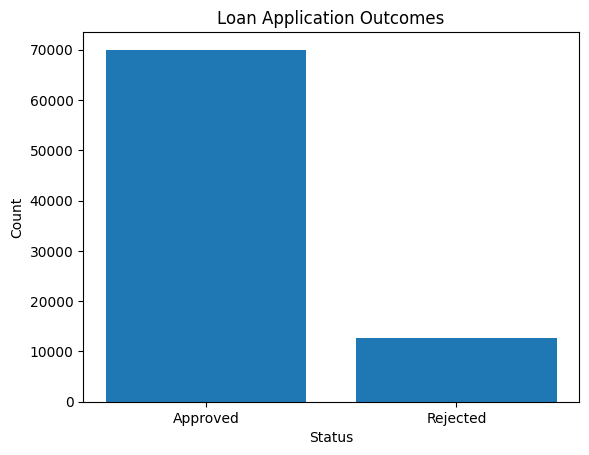

In [77]:
approval_counts = applications['Approval_Status'].value_counts()

plt.figure()
plt.bar(approval_counts.index, approval_counts.values)
plt.title("Loan Application Outcomes")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [78]:
approval_rate = applications['Approval_Status'].value_counts(normalize=True) * 100
print(approval_rate)

Approval_Status
Approved    84.745763
Rejected    15.254237
Name: proportion, dtype: float64


## Rejection Reason Analysis

Identifying the most common reasons for loan rejection.

In [79]:
rejected_apps = applications[applications['Approval_Status'] == 'Rejected']

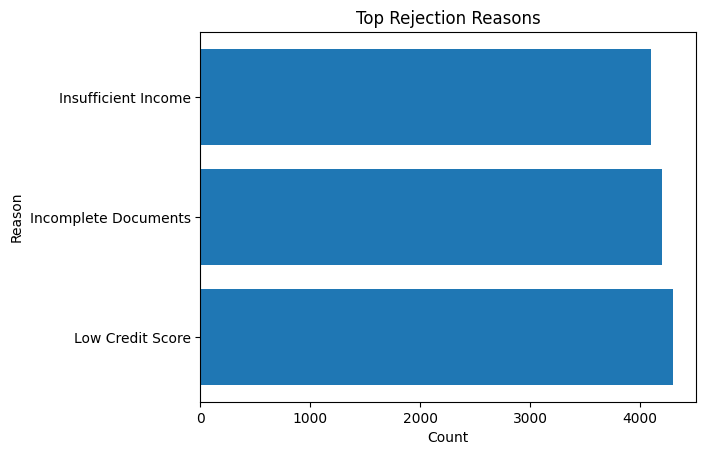

In [80]:
rejection_reasons = rejected_apps['Rejection_Reason'].value_counts().head(10)

plt.figure()
plt.barh(rejection_reasons.index, rejection_reasons.values)
plt.title("Top Rejection Reasons")
plt.xlabel("Count")
plt.ylabel("Reason")
plt.show()

## Processing Fee Comparison

Comparing fees between approved and rejected applications.

In [81]:
fee_comparison = applications.groupby('Approval_Status')['Processing_Fee'].mean()

print(fee_comparison)

Approval_Status
Approved    5252.395014
Rejected    5255.141587
Name: Processing_Fee, dtype: float64


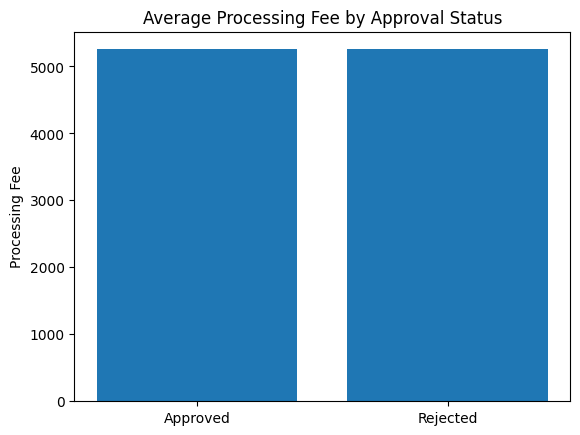

In [82]:
plt.figure()
plt.bar(fee_comparison.index, fee_comparison.values)
plt.title("Average Processing Fee by Approval Status")
plt.ylabel("Processing Fee")
plt.show()

## Processing Time Analysis

Evaluating efficiency of loan approval process.

In [83]:
processing_time = applications.groupby('Approval_Status')['Processing_Time'].mean()

print(processing_time)

Approval_Status
Approved    175.396157
Rejected           NaN
Name: Processing_Time, dtype: float64


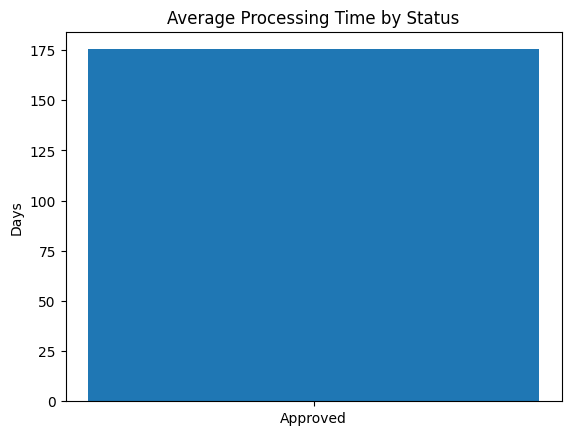

In [84]:
plt.figure()
plt.bar(processing_time.index, processing_time.values)
plt.title("Average Processing Time by Status")
plt.ylabel("Days")
plt.show()

## Key Insights

- Approval rates indicate the efficiency of the credit evaluation process.
- A significant portion of applications may be rejected due to a few dominant reasons.
- Common rejection reasons highlight gaps in customer qualification or underwriting criteria.
- Processing fees may differ between approved and rejected applications, impacting customer experience.
- Processing time differences indicate potential inefficiencies in approval workflows.

## Recommendations

1. Streamline approval criteria to improve conversion rates without increasing risk.
2. Address top rejection reasons through better pre-screening or customer education.
3. Optimize processing fee structure to enhance customer experience.
4. Reduce processing time through workflow automation and prioritization.
5. Implement pre-qualification tools to filter low-probability applications early.

In [85]:
purpose_approval = applications.groupby('Loan_Purpose')['Approval_Status'].value_counts(normalize=True).unstack()

print(purpose_approval)

Approval_Status  Approved  Rejected
Loan_Purpose                       
Business         0.847258  0.152742
Education        0.852765  0.147235
Home Renovation  0.843520  0.156480
Personal         0.846714  0.153286
Vehicle          0.847092  0.152908


# Task 10: Recovery Effectiveness

## Objective
Evaluate how effectively defaulted loans are recovered and identify factors influencing recovery performance.

## Overall Recovery Effectiveness

Measuring the proportion of defaulted amount that is recovered.

In [86]:
defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']

In [87]:
overall_recovery = defaults['Recovery_Rate'].mean()
print("Overall Recovery Rate:", overall_recovery)

Overall Recovery Rate: 0.4045575104592999


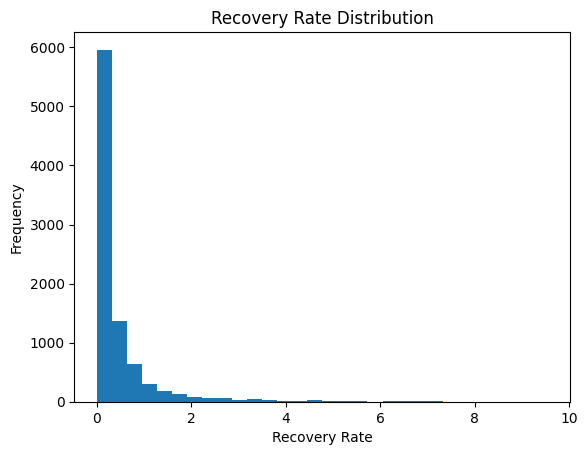

In [88]:
plt.figure()
plt.hist(defaults['Recovery_Rate'].dropna(), bins=30)
plt.title("Recovery Rate Distribution")
plt.xlabel("Recovery Rate")
plt.ylabel("Frequency")
plt.show()

## Recovery Comparison: Legal vs Non-Legal

Evaluating effectiveness of legal interventions in recovery.

In [89]:
legal_recovery = defaults.groupby('Legal_Action')['Recovery_Rate'].mean()

print(legal_recovery)

Legal_Action
No     0.401805
Yes    0.407372
Name: Recovery_Rate, dtype: float64


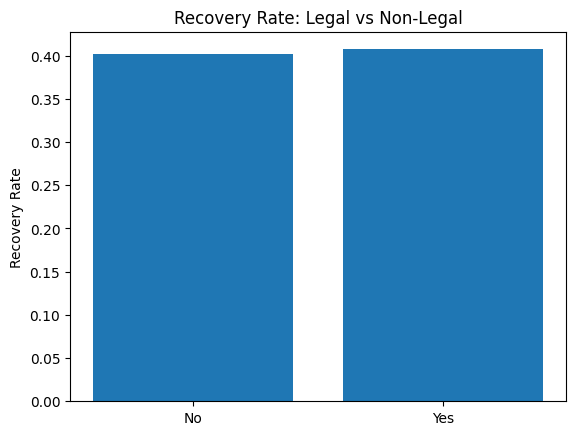

In [90]:
plt.figure()
plt.bar(legal_recovery.index, legal_recovery.values)
plt.title("Recovery Rate: Legal vs Non-Legal")
plt.ylabel("Recovery Rate")
plt.show()

## Recovery by Default Reason

Understanding which types of defaults are easier to recover.

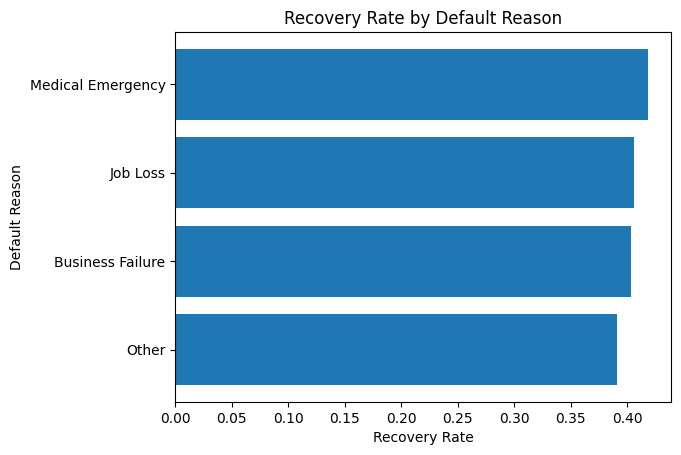

In [91]:
reason_recovery = defaults.groupby('Default_Reason')['Recovery_Rate'].mean().sort_values()

plt.figure()
plt.barh(reason_recovery.index, reason_recovery.values)
plt.title("Recovery Rate by Default Reason")
plt.xlabel("Recovery Rate")
plt.ylabel("Default Reason")
plt.show()

## Branch-Level Recovery Performance

Evaluating recovery effectiveness across branches (via region mapping).

In [92]:
default_region = defaults.merge(
    loans[['Loan_ID', 'Customer_ID']],
    on='Loan_ID',
    how='left'
).merge(
    customers[['Customer_ID', 'Region']],
    left_on='Customer_ID_x',
    right_on = "Customer_ID",
    how='left'
)

In [93]:
region_recovery = default_region.groupby('Region')['Recovery_Rate'].mean().reset_index()

In [94]:
branch_recovery = branches.merge(region_recovery, on='Region', how='left')

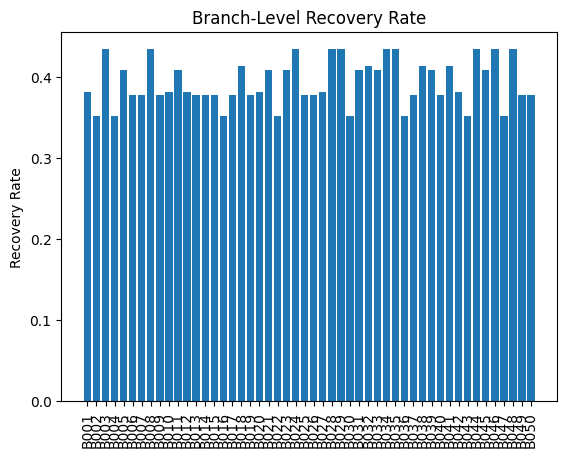

In [95]:
plt.figure()
plt.bar(branch_recovery['Branch_ID'], branch_recovery['Recovery_Rate'])
plt.xticks(rotation=90)
plt.title("Branch-Level Recovery Rate")
plt.ylabel("Recovery Rate")
plt.show()

## Key Insights

- Overall recovery rate provides a benchmark for portfolio loss mitigation.
- Legal actions tend to improve recovery rates but may involve additional costs.
- Recovery effectiveness varies significantly by default reason, indicating different recovery complexities.
- Regional differences suggest varying effectiveness of collection teams and strategies.

## Recommendations

1. Optimize legal recovery strategies by balancing cost and recovery effectiveness.
2. Prioritize recovery efforts for default types with higher recovery potential.
3. Strengthen collection teams in regions with lower recovery rates.
4. Develop standardized recovery frameworks across branches.
5. Track recovery KPIs regularly to improve portfolio performance.

In [96]:
defaults['Loss_Given_Default'] = 1 - defaults['Recovery_Rate']

print(defaults['Loss_Given_Default'].mean())

0.5954424895407002


# Task 11: Loan Disbursement Efficiency

## Objective
Analyze the efficiency of loan processing and disbursement to identify bottlenecks and improve turnaround time.

## Application to Disbursement Time

Measuring the time taken from application submission to loan disbursement.

In [97]:
process_df = loans.merge(
    applications[['Loan_ID', 'Application_Date', 'Approval_Date']],
    on='Loan_ID',
    how='left'
)

In [98]:
process_df['Disbursement_Time'] = (
    process_df['Disbursal_Date'] - process_df['Application_Date']
).dt.days

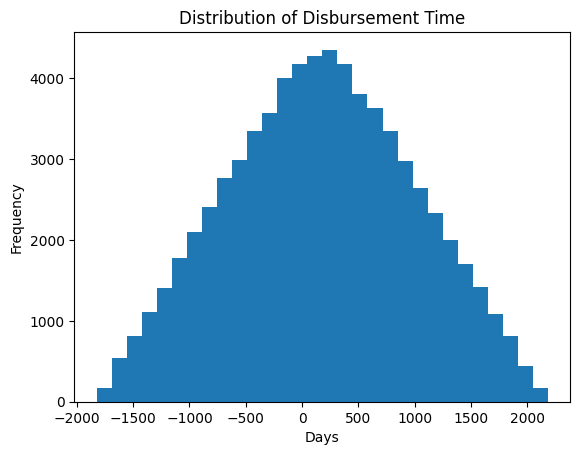

In [99]:
plt.figure()
plt.hist(process_df['Disbursement_Time'].dropna(), bins=30)
plt.title("Distribution of Disbursement Time")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

In [100]:
print("Average Disbursement Time:", process_df['Disbursement_Time'].mean())

Average Disbursement Time: 171.87647811256394


## Branch-Level Processing Efficiency

Comparing processing times across branches.

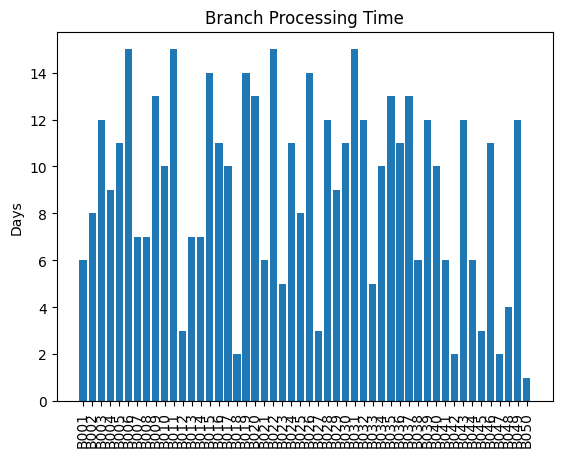

In [101]:
plt.figure()
plt.bar(branches['Branch_ID'], branches['Avg_Processing_Time'])
plt.xticks(rotation=90)
plt.title("Branch Processing Time")
plt.ylabel("Days")
plt.show()

In [102]:
slow_branches = branches.sort_values(by='Avg_Processing_Time', ascending=False).head(10)
print(slow_branches[['Branch_ID', 'Avg_Processing_Time']])

   Branch_ID  Avg_Processing_Time
10      B011                   15
5       B006                   15
30      B031                   15
21      B022                   15
14      B015                   14
25      B026                   14
18      B019                   14
8       B009                   13
34      B035                   13
19      B020                   13


## Regional Processing Efficiency

Analyzing differences in processing speed across regions.

In [103]:
region_time = branches.groupby('Region')['Avg_Processing_Time'].mean()

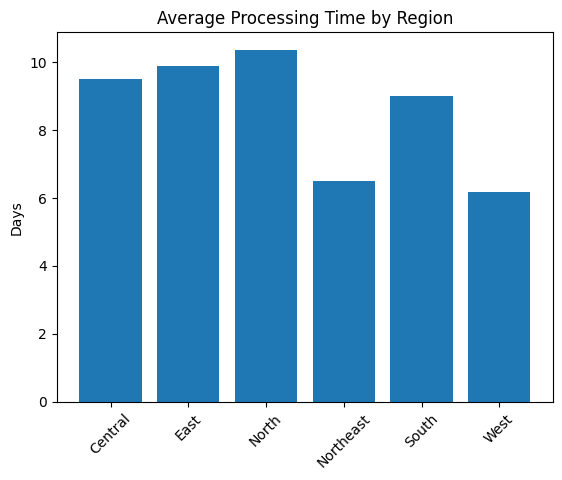

In [104]:
plt.figure()
plt.bar(region_time.index, region_time.values)
plt.xticks(rotation=45)
plt.title("Average Processing Time by Region")
plt.ylabel("Days")
plt.show()

## Disbursement Trends by Loan Purpose

Evaluating how loan disbursement varies across purposes.

In [105]:
loans = loans.merge(
    applications[['Loan_ID', 'Loan_Purpose']],
    on='Loan_ID',
    how='left'
)

loans['Loan_Purpose'] = loans['Loan_Purpose_x'].fillna('Unknown')

In [106]:
purpose_disbursement = loans.groupby('Loan_Purpose')['Loan_Amount'].sum().sort_values()

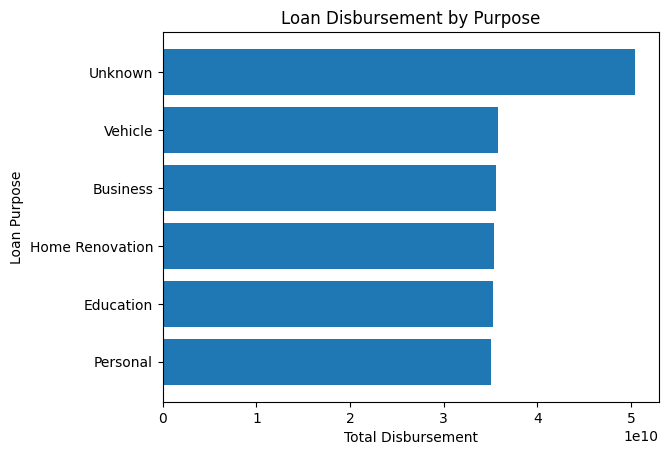

In [107]:
plt.figure()
plt.barh(purpose_disbursement.index, purpose_disbursement.values)
plt.title("Loan Disbursement by Purpose")
plt.xlabel("Total Disbursement")
plt.ylabel("Loan Purpose")
plt.show()

## Disbursement Trends by Region

Analyzing geographic distribution of loan disbursement.

In [108]:
loan_region = loans.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)

In [109]:
region_disb = loan_region.groupby('Region')['Loan_Amount'].sum()

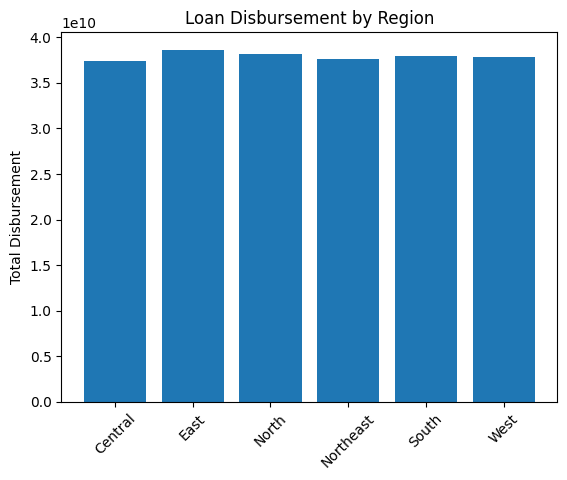

In [110]:
plt.figure()
plt.bar(region_disb.index, region_disb.values)
plt.xticks(rotation=45)
plt.title("Loan Disbursement by Region")
plt.ylabel("Total Disbursement")
plt.show()

## Key Insights

- Disbursement time varies significantly, indicating inconsistencies in processing efficiency.
- Certain branches consistently exhibit higher processing times, pointing to operational bottlenecks.
- Regional differences suggest uneven operational performance across geographies.
- Loan disbursement is concentrated in specific purposes, indicating business focus areas.
- Geographic concentration of disbursement highlights market dependency on certain regions.

## Recommendations

1. Identify and optimize bottlenecks in high processing time branches.
2. Standardize loan approval workflows across regions to reduce variability.
3. Implement automation to reduce manual delays in processing.
4. Allocate resources dynamically during peak demand periods.
5. Diversify loan portfolio across regions and purposes to reduce concentration risk.

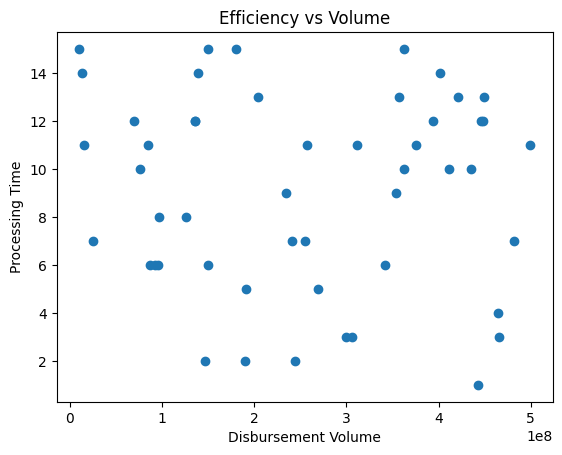

In [111]:
plt.figure()
plt.scatter(branches['Loan_Disbursement_Amount'], branches['Avg_Processing_Time'])
plt.xlabel("Disbursement Volume")
plt.ylabel("Processing Time")
plt.title("Efficiency vs Volume")
plt.show()

# Task 12: Profitability Analysis

## Objective
Evaluate the profitability of the loan portfolio by analyzing interest income, loan segments, and branch-level performance.

## Total Interest Income

Estimating total interest income generated across all loans.

In [112]:
loans['Total_Payment'] = loans['EMI_Amount'] * loans['Loan_Term']
loans['Interest_Income'] = loans['Total_Payment'] - loans['Loan_Amount']

In [113]:
total_interest = loans['Interest_Income'].sum()

print("Total Interest Income:", total_interest)

Total Interest Income: -61647258235.0


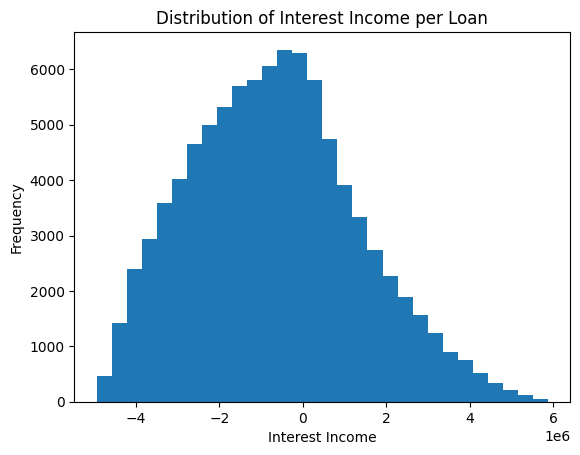

In [114]:
plt.figure()
plt.hist(loans['Interest_Income'].dropna(), bins=30)
plt.title("Distribution of Interest Income per Loan")
plt.xlabel("Interest Income")
plt.ylabel("Frequency")
plt.show()

## Profitability by Loan Purpose

Identifying which loan categories generate the most revenue.

In [115]:
purpose_profit = loans.groupby('Loan_Purpose')['Interest_Income'].sum().sort_values()

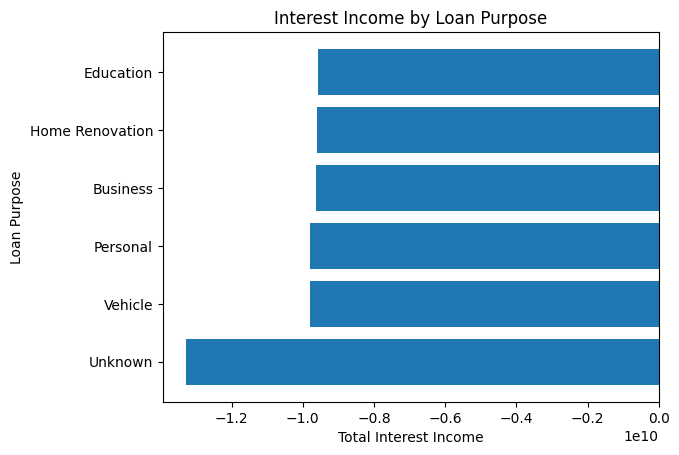

In [116]:
plt.figure()
plt.barh(purpose_profit.index, purpose_profit.values)
plt.title("Interest Income by Loan Purpose")
plt.xlabel("Total Interest Income")
plt.ylabel("Loan Purpose")
plt.show()

## Profitability vs Default Risk

Understanding trade-off between revenue and risk.

In [117]:
profit_df = loans.merge(
    defaults[['Loan_ID', 'Default_Amount']],
    on='Loan_ID',
    how='left'
)

profit_df['Default_Amount'] = profit_df['Default_Amount'].fillna(0)

In [118]:
profit_df['Net_Profit'] = profit_df['Interest_Income'] - profit_df['Default_Amount']

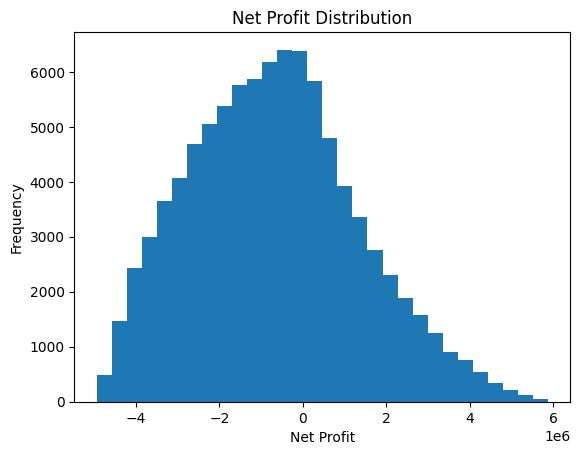

In [119]:
plt.figure()
plt.hist(profit_df['Net_Profit'].dropna(), bins=30)
plt.title("Net Profit Distribution")
plt.xlabel("Net Profit")
plt.ylabel("Frequency")
plt.show()

## Branch-Level Profitability

Evaluating profitability across branches (via region mapping).

In [120]:
loan_region = profit_df.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)

In [121]:
region_profit = loan_region.groupby('Region')['Net_Profit'].sum().reset_index()

In [122]:
branch_profit = branches.merge(region_profit, on='Region', how='left')

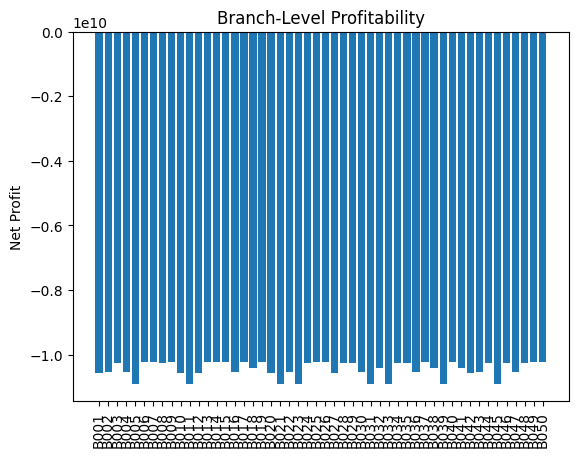

In [123]:
plt.figure()
plt.bar(branch_profit['Branch_ID'], branch_profit['Net_Profit'])
plt.xticks(rotation=90)
plt.title("Branch-Level Profitability")
plt.ylabel("Net Profit")
plt.show()

## Key Insights

- Interest income is concentrated among a subset of high-value loans.
- Certain loan purposes contribute disproportionately to overall profitability.
- High-interest loans may also carry higher default risk, creating a trade-off.
- Net profitability varies significantly across regions, indicating uneven portfolio performance.
- Some branches generate high revenue but may also carry higher risk exposure.

## Recommendations

1. Focus on expanding high-profit loan segments with controlled risk.
2. Balance interest income growth with default risk to optimize net profitability.
3. Identify and scale profitable loan purposes.
4. Improve risk controls in high-revenue but high-default segments.
5. Align branch incentives with net profitability rather than just disbursement volume.

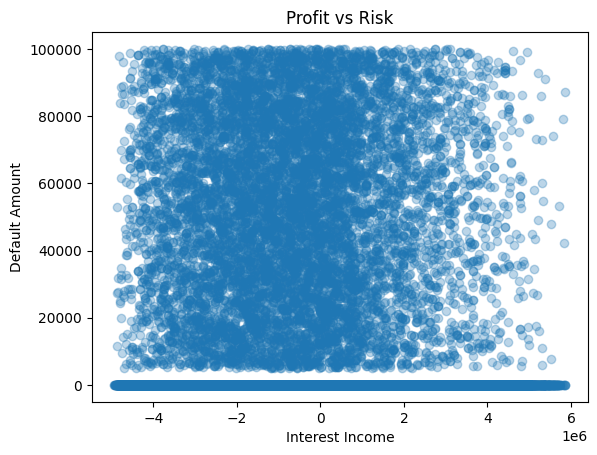

In [124]:
plt.figure()
plt.scatter(profit_df['Interest_Income'], profit_df['Default_Amount'], alpha=0.3)
plt.xlabel("Interest Income")
plt.ylabel("Default Amount")
plt.title("Profit vs Risk")
plt.show()

# Task 13: Geospatial Analysis

## Objective
Analyze geographic distribution of loans and defaults to identify regional trends and risk concentration.

## Distribution of Active Loans by Region

Understanding how loan exposure is distributed geographically.

In [125]:
loan_region = loans.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)

In [126]:
region_loans = loan_region.groupby('Region')['Loan_ID'].count().sort_values()

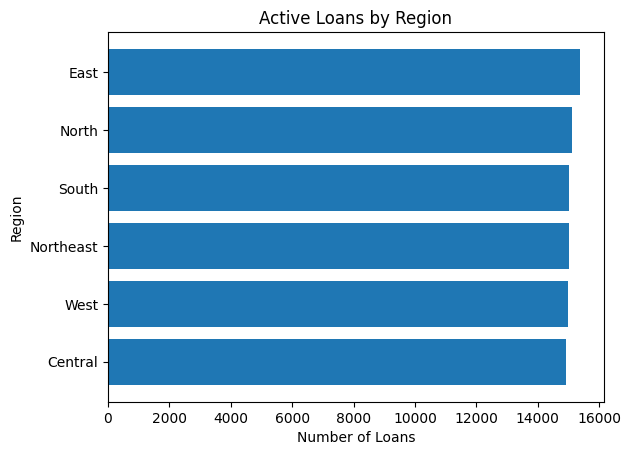

In [127]:
plt.figure()
plt.barh(region_loans.index, region_loans.values)
plt.title("Active Loans by Region")
plt.xlabel("Number of Loans")
plt.ylabel("Region")
plt.show()

## Default Rate by Region

Analyzing geographic risk concentration.

In [128]:
region_default = loan_region.groupby('Region')['Default_Flag'].mean().sort_values()

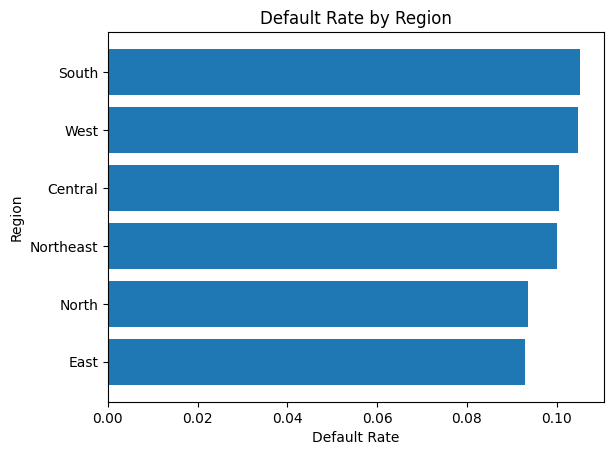

In [129]:
plt.figure()
plt.barh(region_default.index, region_default.values)
plt.title("Default Rate by Region")
plt.xlabel("Default Rate")
plt.ylabel("Region")
plt.show()

## Rural vs Urban Loan Distribution

Comparing loan and risk patterns across rural and urban regions.

In [130]:
loan_geo = loans.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)

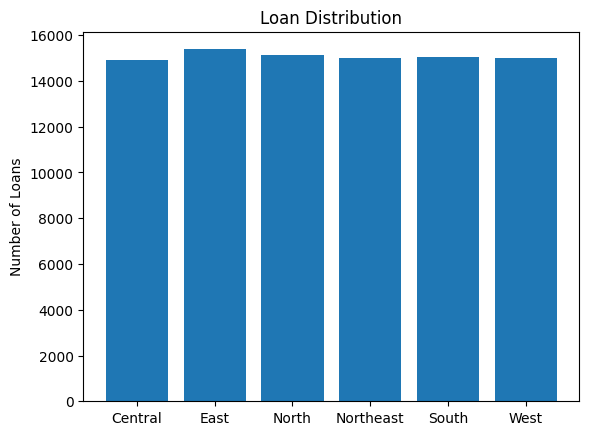

In [131]:
geo_loans = loan_geo.groupby('Region')['Loan_ID'].count()

plt.figure()
plt.bar(geo_loans.index, geo_loans.values)
plt.title("Loan Distribution")
plt.ylabel("Number of Loans")
plt.show()

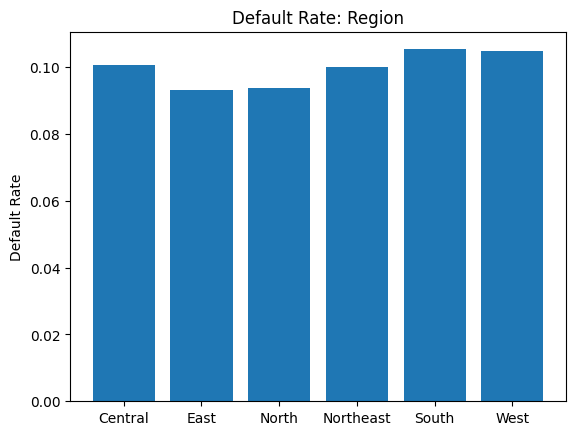

In [132]:
geo_default = loan_geo.groupby('Region')['Default_Flag'].mean()

plt.figure()
plt.bar(geo_default.index, geo_default.values)
plt.title("Default Rate: Region")
plt.ylabel("Default Rate")
plt.show()

## Key Insights

- Loan distribution is uneven across regions, indicating geographic concentration of exposure.
- Certain regions exhibit significantly higher default rates, highlighting localized risk.
- High-loan regions are not always high-risk, suggesting differences in portfolio quality.
- Geographic segmentation reveals potential market expansion or contraction opportunities.
- Rural vs urban patterns (if available) show differences in risk and loan behavior.

## Recommendations

1. Strengthen risk controls in high-default regions.
2. Expand operations in regions with high volume and low default rates.
3. Develop region-specific lending strategies based on risk profile.
4. Customize products for rural vs urban markets if behavioral differences exist.
5. Monitor geographic concentration risk to avoid overexposure.

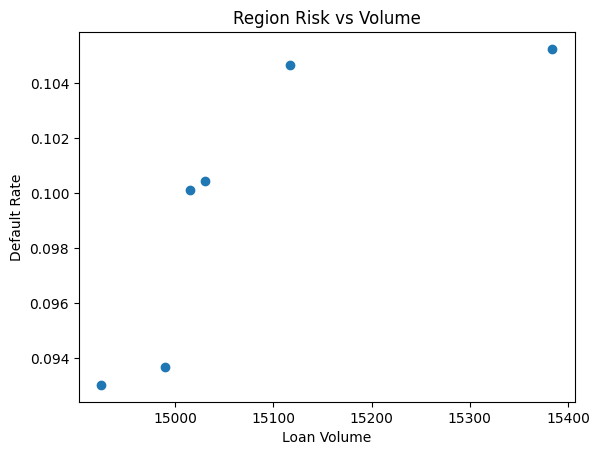

In [133]:
plt.figure()
plt.scatter(region_loans.values, region_default.values)

plt.xlabel("Loan Volume")
plt.ylabel("Default Rate")
plt.title("Region Risk vs Volume")

plt.show()

# Task 14: Default Trends

## Objective
Analyze temporal patterns and segmentation of defaults to identify trends and high-risk groups.

## Defaults Over Time

Understanding how default frequency changes over time.

In [134]:
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'])
defaults['Month'] = defaults['Default_Date'].dt.to_period('M').astype(str)

In [135]:
monthly_defaults = defaults.groupby('Month').size()

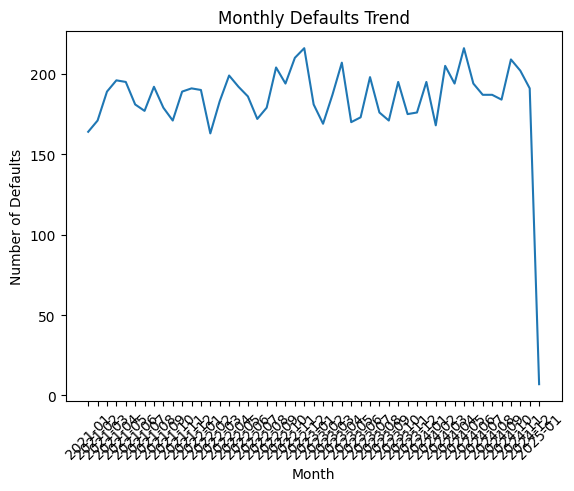

In [136]:
plt.figure()
plt.plot(monthly_defaults.index, monthly_defaults.values)
plt.xticks(rotation=45)
plt.title("Monthly Defaults Trend")
plt.xlabel("Month")
plt.ylabel("Number of Defaults")
plt.show()

## Average Default Amount by Loan Purpose

Identifying which loan types lead to higher losses.

In [137]:
default_purpose = defaults.merge(
    loans[['Loan_ID']],
    on='Loan_ID',
    how='left'
).merge(
    applications[['Loan_ID', 'Loan_Purpose']],
    on='Loan_ID',
    how='left'
)

default_purpose['Loan_Purpose'] = default_purpose['Loan_Purpose'].fillna('Unknown')

In [138]:
avg_default_amt = default_purpose.groupby('Loan_Purpose')['Default_Amount'].mean().sort_values()

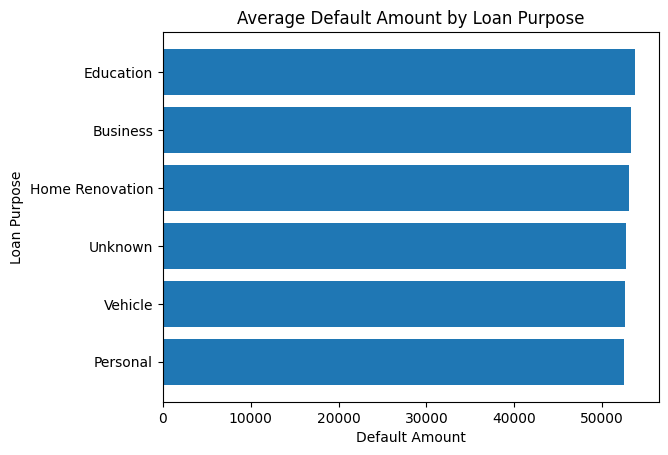

In [139]:
plt.figure()
plt.barh(avg_default_amt.index, avg_default_amt.values)
plt.title("Average Default Amount by Loan Purpose")
plt.xlabel("Default Amount")
plt.ylabel("Loan Purpose")
plt.show()

## Default Rate by Income Category

Understanding how income levels influence default behavior.

In [140]:
customers['Income_Bucket'] = pd.cut(
    customers['Annual_Income'],
    bins=[0, 300000, 700000, 1500000, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [141]:
loan_income = loans.merge(
    customers[['Customer_ID', 'Income_Bucket']],
    on='Customer_ID',
    how='left'
)

In [142]:
income_default = loan_income.groupby('Income_Bucket')['Default_Flag'].mean()

/tmp/ipykernel_587/3052387137.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = loan_income.groupby('Income_Bucket')['Default_Flag'].mean()


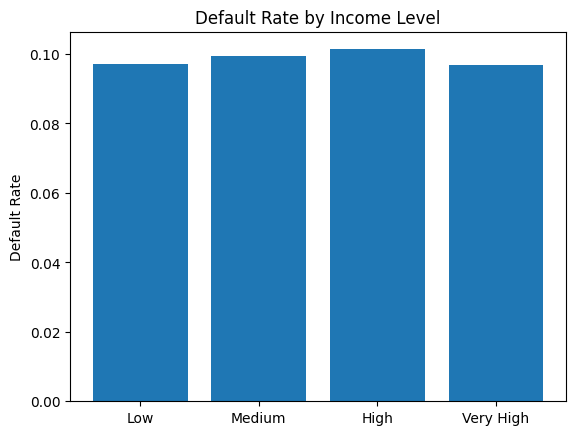

In [143]:
plt.figure()
plt.bar(income_default.index, income_default.values)
plt.title("Default Rate by Income Level")
plt.ylabel("Default Rate")
plt.show()

## Key Insights

- Default trends over time reveal potential increases or seasonality in risk.
- Certain loan purposes are associated with higher average default amounts, indicating higher loss severity.
- Lower income segments exhibit higher default rates, highlighting financial vulnerability.
- High-income customers tend to have lower default probability, indicating better repayment capacity.

## Recommendations

1. Monitor default trends regularly to detect early signs of portfolio deterioration.
2. Apply stricter controls on loan purposes with high default severity.
3. Introduce income-based risk thresholds in loan approvals.
4. Develop targeted repayment support for low-income borrowers.
5. Incorporate time-based risk indicators into credit models.

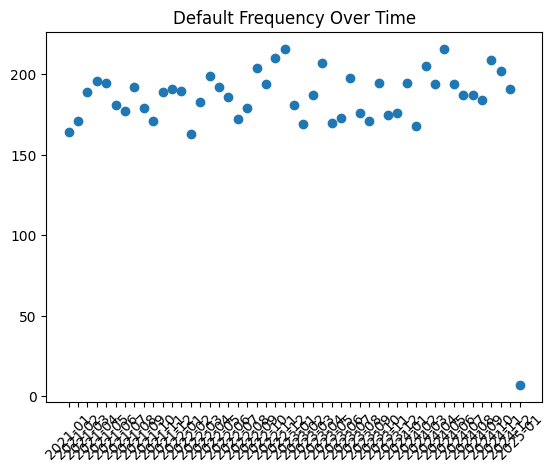

In [144]:
plt.figure()
plt.scatter(monthly_defaults.index, monthly_defaults.values)
plt.xticks(rotation=45)
plt.title("Default Frequency Over Time")
plt.show()

# Task 15: Branch Efficiency

## Objective
Evaluate branch-level efficiency in loan processing, approval outcomes, and operational performance.

## Average Loan Disbursement Time by Branch

Analyzing how quickly branches process loans from application to disbursement.

In [146]:
process_df = loans.merge(
    applications[['Loan_ID', 'Application_Date']],
    on='Loan_ID',
    how='left'
)

process_df['Disbursement_Time'] = (
    process_df['Disbursal_Date'] - process_df['Application_Date']
).dt.days

In [147]:
process_df = process_df.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)

In [148]:
region_time = process_df.groupby('Region')['Disbursement_Time'].mean().sort_values()

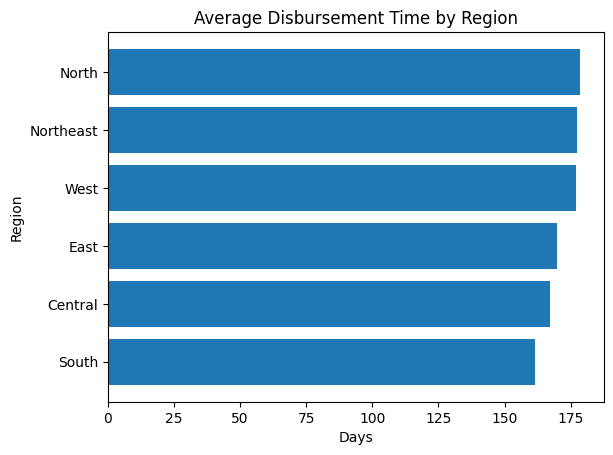

In [149]:
plt.figure()
plt.barh(region_time.index, region_time.values)
plt.title("Average Disbursement Time by Region")
plt.xlabel("Days")
plt.ylabel("Region")
plt.show()

## Branches with Highest Rejection Rates

Identifying branches struggling with approvals.

In [152]:
app_region = applications.merge(
    loans[['Loan_ID', 'Customer_ID']],
    on='Loan_ID',
    how='left'
).merge(
    customers[['Customer_ID', 'Region']],
    left_on='Customer_ID_x',
    right_on = 'Customer_ID' ,
    how='left'
)

In [153]:
app_region['Rejected'] = (app_region['Approval_Status'] == 'Rejected').astype(int)

rejection_rate = app_region.groupby('Region')['Rejected'].mean().sort_values()

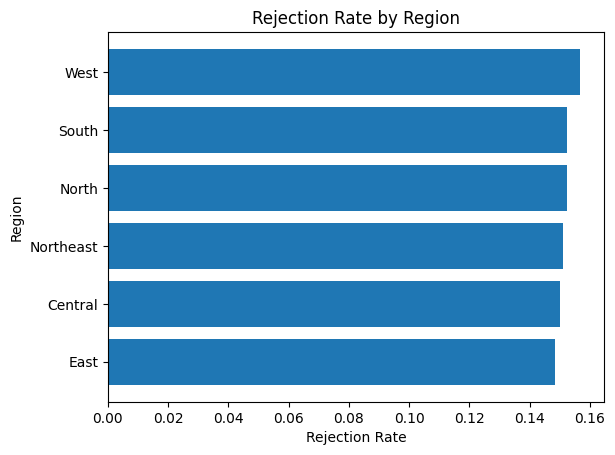

In [154]:
plt.figure()
plt.barh(rejection_rate.index, rejection_rate.values)
plt.title("Rejection Rate by Region")
plt.xlabel("Rejection Rate")
plt.ylabel("Region")
plt.show()

## Combined Efficiency Analysis

Comparing processing time and rejection rates across regions.

In [155]:
efficiency_df = pd.DataFrame({
    'Processing_Time': region_time,
    'Rejection_Rate': rejection_rate
}).dropna()

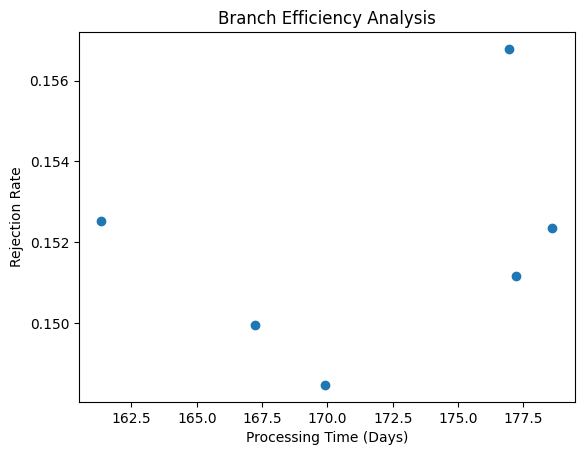

In [156]:
plt.figure()
plt.scatter(efficiency_df['Processing_Time'], efficiency_df['Rejection_Rate'])

plt.xlabel("Processing Time (Days)")
plt.ylabel("Rejection Rate")
plt.title("Branch Efficiency Analysis")

plt.show()

## Key Insights

- Significant variation exists in disbursement time across regions, indicating operational inconsistency.
- Regions with higher rejection rates may indicate stricter underwriting or poor applicant quality.
- Some regions exhibit both high processing time and high rejection rates, signaling inefficiency.
- Efficient regions balance low processing time with reasonable approval rates.

## Recommendations

1. Investigate regions with high processing time and optimize workflows.
2. Improve pre-screening in regions with high rejection rates.
3. Replicate best practices from high-efficiency regions.
4. Introduce SLA-based monitoring for loan processing time.
5. Align branch performance metrics with both efficiency and approval outcomes.

/tmp/ipykernel_587/4240707367.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (efficiency_df['Processing_Time'][i], efficiency_df['Rejection_Rate'][i]))


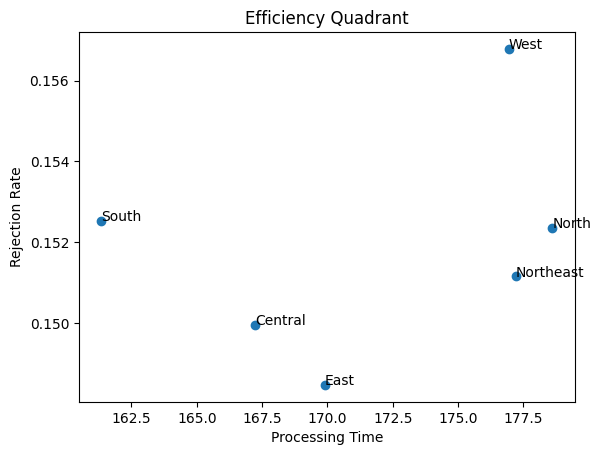

In [157]:
plt.figure()
plt.scatter(efficiency_df['Processing_Time'], efficiency_df['Rejection_Rate'])

for i, txt in enumerate(efficiency_df.index):
    plt.annotate(txt, (efficiency_df['Processing_Time'][i], efficiency_df['Rejection_Rate'][i]))

plt.xlabel("Processing Time")
plt.ylabel("Rejection Rate")
plt.title("Efficiency Quadrant")
plt.show()